# ML from DFT data

- [ ] learn on separated FM and NM AGAIN
- [ ] remove high order BOP features before learing
- [X] Recursive Feature elimination after removing high order features
- [ ] make recursion on bond energy
- [X] change OS to 1/10,
- [X] 1/10 OS and scf bop
- [ ] scaled bond integrals
- learn form library features
- compare different regression methods
   - Linear regression
   - add SVM
   - kernel methods
   - Gaussian process.
- compare different test-train splittings
- Learn on increasing domain knowledge

 - input: clean features dataframes from pickles
 - output : plots and Models

In [1]:
from Tools.DatasetTools.Commoms import *

In [2]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=22)
from matplotlib.lines import Line2D

# Parameters 

In [3]:
from Tools.DatasetTools.DatasetOperator import Dataset, DatasetTester

['/home/storage/fortimtb/DatasetsML', '/home/storage/fortimtb/DatasetsML', '/scratch/AnacondaEnvironments/ml_datasets/lib/python39.zip', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/lib-dynload', '', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/ipython_genutils-0.2.0-py3.9.egg', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/webencodings-0.5.1-py3.9.egg', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/maxvolpy-0.3.8-py3.9-linux-x86_64.egg']


In [4]:
target_case = 'EF_nmhcp'

In [5]:
DS = Dataset('Fe-Mo', target_name=target_case)

Possible models are: **Kernel Ridge, MLP and Random Forest**

In [6]:
ModelName = 'Kernel Ridge'

In [7]:
suffix = 'CV_stratified_folds'

# Targets

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


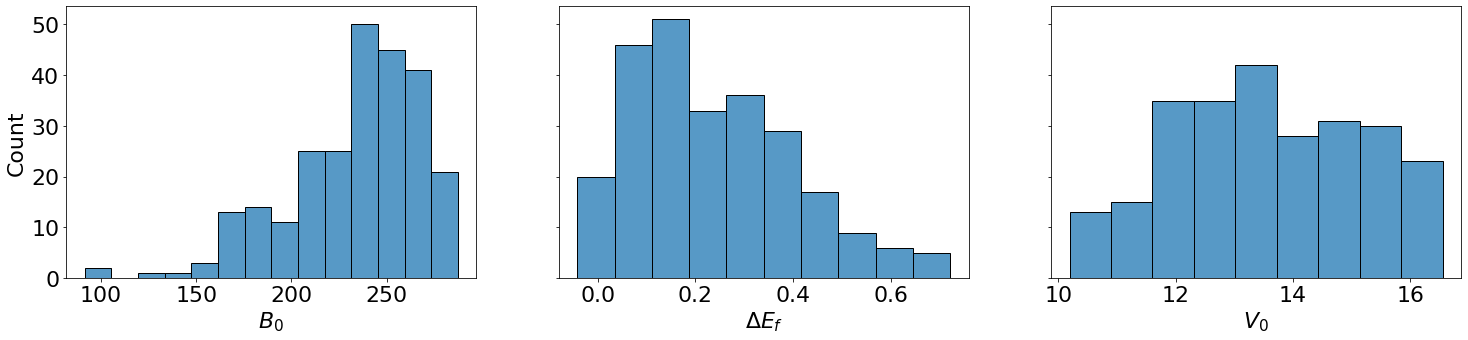

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(25, 5), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0])
sns.histplot( DS.BS[target_case], ax= ax[1])
sns.histplot( DS.BS['V0'], ax= ax[2])
ax[0].set_xlabel('$B_0$')
ax[1].set_xlabel(r'$\Delta E_f$')
ax[2].set_xlabel('$V_0$')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_target_distributions_{target_case}.eps')

# Machine Learning 

In [9]:
from Tools.DatasetTools.MLConveniences import *

In [10]:
resultslocation = DS.resultslocation

## Feature sets

In [11]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [12]:
Features['ACE'] = Features['ACE_CNAV'].filter(regex='_0$|Mag|Structure')

## BOP features with and without CP averages

In [13]:
def clean_CNAVS(name: str, features: pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_CN)')
    else:
        return features

In [14]:
def clean_zeros(name: str, features: pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_0$)')
    else:
        return features

In [15]:
def notyetclean(name: str):
    return ('BOP' in name) and ('CNAV' not in name) and ('Zeros' not in name)

In [16]:
Features.update({name+' no CNAV': clean_CNAVS(name, features) for name, features in Features.items() if notyetclean(name)})

In [17]:
# Features.update({name+' no Zeros': clean_zeros(name, features) for name, features in Features.items() if notyetclean(name)} )

## test - train splits

In [18]:
samplesplit = DS.get_samplesplit()

(array([14., 12., 12.,  3.,  1.,  2.,  5.,  2.,  2.,  2.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 10 artists>)

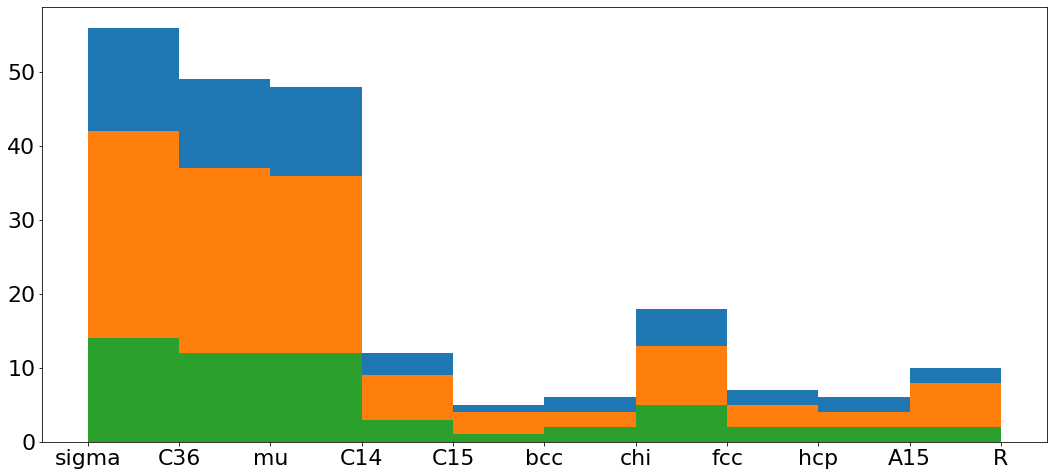

In [19]:
plt.hist(DS.StructureNames)

plt.hist(DS.StructureNames.loc[samplesplit['train']])
plt.hist(DS.StructureNames.loc[samplesplit['test']])

# Models: adjust params

In [20]:
import warnings
warnings.simplefilter('ignore')

In [21]:
Models = {
    'Kernel Ridge': Pipeline([('scaler', StandardScaler()), ('regressor', KernelRidge())]),
    'MLP': Pipeline([('scaler', StandardScaler()), ('regressor', MLPRegressor())]),
    'Random Forest': Pipeline([('regressor', RandomForestRegressor())]),
    'Gaussian Process': Pipeline([('regressor', GaussianProcessRegressor())])
}

In [22]:
from importlib.machinery import SourceFileLoader
MO = SourceFileLoader('MO', 'Tools/DatasetTools/ModelSelection.py').load_module().ModelOptions(DS.dataset)

In [23]:
MO.load_model_options(ModelName)

In [24]:
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, RationalQuadratic, ConstantKernel, ExpSineSquared, DotProduct, Product

# Feature Selection

In [25]:
FeatureConcatenate = SourceFileLoader('FeatureConcatenate', 'Tools/DatasetTools/FeatureConcatenate.py').load_module().NewFeatureConcatenate
# from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate

['/home/storage/fortimtb/DatasetsML', 'Tools/DatasetTools', '/home/storage/fortimtb/DatasetsML', '/home/storage/fortimtb/DatasetsML', '/scratch/AnacondaEnvironments/ml_datasets/lib/python39.zip', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/lib-dynload', '', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/ipython_genutils-0.2.0-py3.9.egg', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/webencodings-0.5.1-py3.9.egg', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/maxvolpy-0.3.8-py3.9-linux-x86_64.egg']


In [26]:
feature_concat_resul_loc = os.path.join(DS.dataset, 'results', f'concatenation_results_{target_case}{suffix}.pkl')  
if os.path.exists(feature_concat_resul_loc):
    with open(feature_concat_resul_loc, 'rb') as pkl:
        FCresults = pickle.load(pkl)
else:
    FCresults = {}

In [27]:
nowantoplot = ['Projections sOS BOP']

In [28]:
iwanttoplot = [combi[1] for combi in FCresults.keys() if combi[1] not in nowantoplot]

In [29]:
pallete = sns.color_palette(n_colors=len(iwanttoplot))

In [30]:
colors = {name: c for name, c in zip(iwanttoplot, pallete)}

In [31]:
# iwanttoplot = ['atomic', 'dataset', 'Canonical BOP', 'dataset + Canonical BOP', 'Projections BOP', 'dataset + Projections BOP', 'Projections sOS BOP', 'dataset + Projections sOS BOP' ]
#iwanttoplot = ['ACE','SOAP_specific',  'Canonical BOP', 
#iwanttoplot = ['Projections OS BOP']#, 'Projections sOS BOP']#, 'SOAP_canonicalW',

In [32]:
from sklearn.model_selection import StratifiedKFold
folder = StratifiedKFold(shuffle=True)
folds_generator = folder.split(DS.samplesplit['train'], DS.StructureNames[DS.samplesplit['train']])
train_folds = list(folds_generator)
TestCV = GridSearchCV(Models[ModelName], MO.modeloptions, cv = train_folds, return_train_score=True)

In [33]:
FittedGS = {}

In [34]:
MO.modeloptions

{'Kernel Ridge': {'regressor__alpha': [1.0, 0.1, 0.01],
  'regressor__kernel': ['polynomial'],
  'regressor__degree': [2, 3, 4, 5],
  'regressor__coef0': [0, 1, 2, 3, 4, 5]}}

In [35]:
iwanttoplot

['Projections OS BOP', '0.7 Projections OS BOP']

In [36]:
# DS.Features.keys(): #['Canonical BOP']:
for featurename in iwanttoplot: #FittedModels.items():
    print(featurename)
    if 'random' not in Features[featurename]:
        Features[featurename]['random'] = np.random.rand(DS.target.shape[0])
    corrs = pd.concat([Features[featurename], DS.target], axis=1).corr().abs()[target_case]
    
    reasonable_features = corrs[corrs > corrs['random']].index.difference([target_case])
    combi = (ModelName, featurename)
#   model = copy.deepcopy(fmodel.best_estimator_)
    FittedGS[combi] = copy.deepcopy(TestCV)
    if combi in FCresults.keys():
        continue
    FC = FeatureConcatenate(DS, FittedGS[combi],  MO.modeloptions[ModelName]) #fmodel.best_params_,)model_params_grid =
    FCresults[combi] = FC.get_best_features_list(combi[1], num_features = 2, max_workers=3, search_only = reasonable_features)#DS.Features[combi[1]].shape[1]
    with open(feature_concat_resul_loc, 'wb') as pkl:
        pickle.dump(FCresults, pkl)

Projections OS BOP
0.7 Projections OS BOP


In [37]:
from Tools.DatasetTools.Tools import get_str_formatted

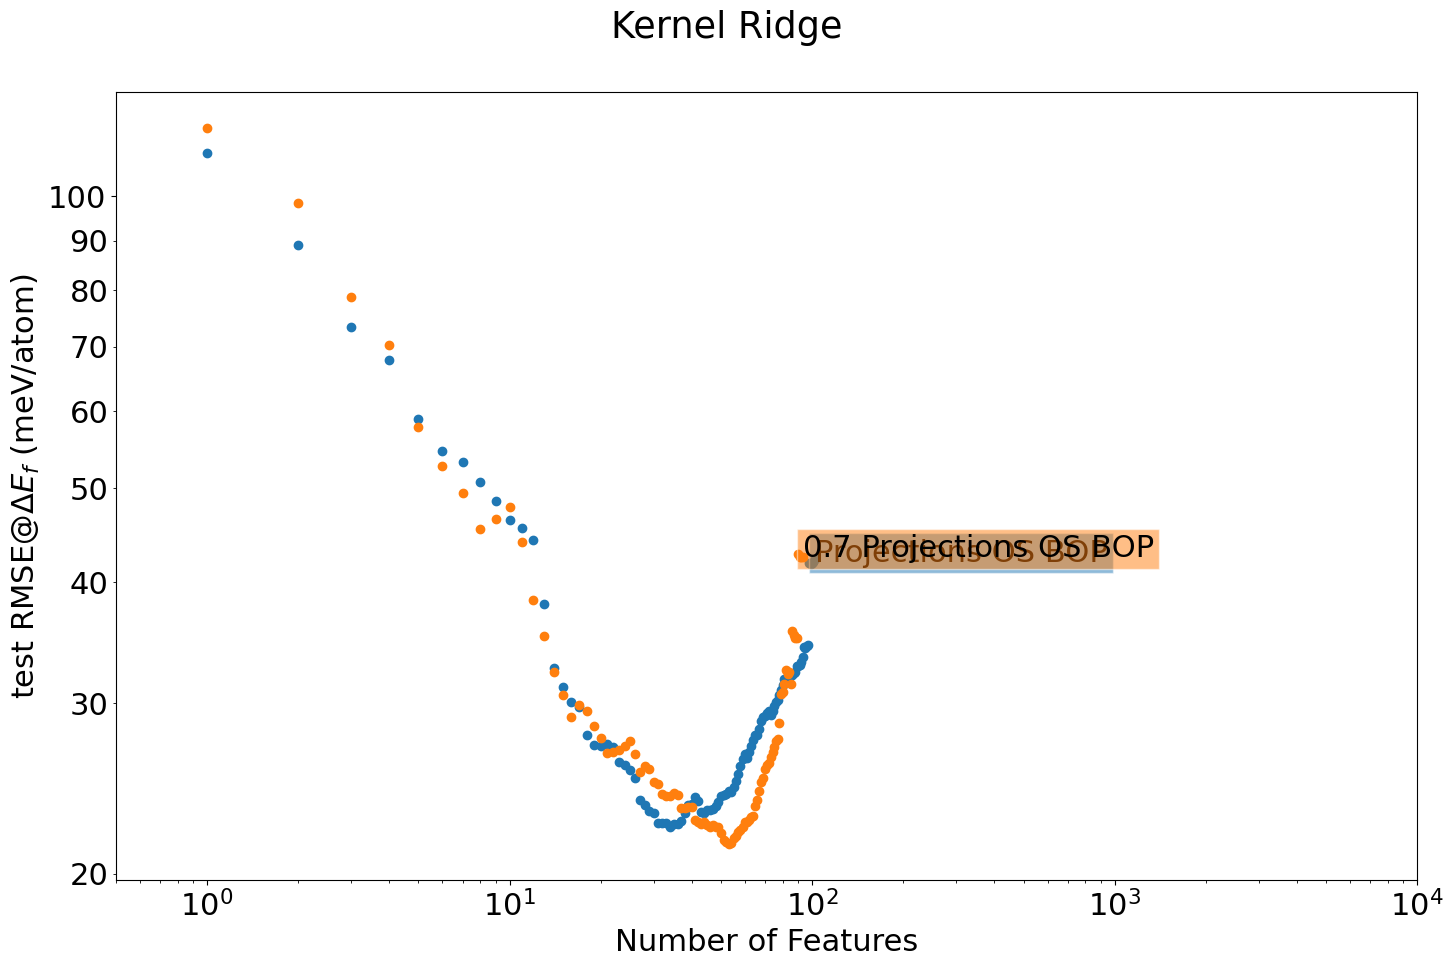

In [38]:
from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots(figsize=(15,10))
for combi, result in FCresults.items():
    if combi[0] != ModelName:
        continue
    if combi[1] not in iwanttoplot:
        continue
#    if ' OS ' in combi[1]:
#        continue
    nfeats = result.shape[0]
    x=np.linspace(1,nfeats, nfeats)
    legend = combi[1].replace('dataset', 'polyhedra')
    legend = legend.replace('atomic', 'Matminer')
    y = result['test']*1000
    axes.plot(x, y ,'o',c=colors[combi[1]], label=legend)
    text = axes.text(x[-1], y[-2], legend, horizontalalignment='left')#, backgroundcolor='white', alpha=0.5)
    text.set_bbox(dict(facecolor=colors[combi[1]], alpha=0.5,edgecolor='white'))
axes.set_xscale('log')
axes.set_ylabel(r'test RMSE@$\Delta E_f$ (meV/atom)')
axes.set_xlabel('Number of Features')
axes.tick_params(axis='y', which='minor')
axes.set_yscale('log')
axes.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
axes.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
#plt.legend(bbox_to_anchor=(0.6,0.5))
axes.set_xlim([0.5, 1e4])
fig.suptitle(ModelName)
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_{target_case}_CV.pdf')

In [39]:
'Mag' in FCresults[('Kernel Ridge', 'Projections OS BOP')].index

True

In [40]:
selected_pos = FCresults[(ModelName, 'Projections OS BOP')].index[0]
y_pos = FCresults[(ModelName, 'Projections OS BOP')]['test']*1000
x = np.linspace(1, len(y_pos), len(y_pos))
axes.annotate(get_str_formatted(selected_pos), (x[0], y_pos[0]-5), xytext=(x[0]-0.1, y_pos[0]-40), arrowprops={'facecolor':'black'})
selected_next = FCresults[(ModelName, 'Projections OS BOP')].index[1]
axes.annotate(get_str_formatted(selected_next), (x[1], y_pos[1]), xytext=(x[1]*2, y_pos[1]+20), arrowprops={'facecolor':'black'})
ymag = y_pos[y_pos.index=='Mag']['Mag']
xmag = x[y_pos.index=='Mag']
axes.annotate('Mag', (xmag-0.1, ymag-1), xytext=(xmag/5, ymag-10), arrowprops={'facecolor':'black'})
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_annotated_{target_case}_CV.pdf')

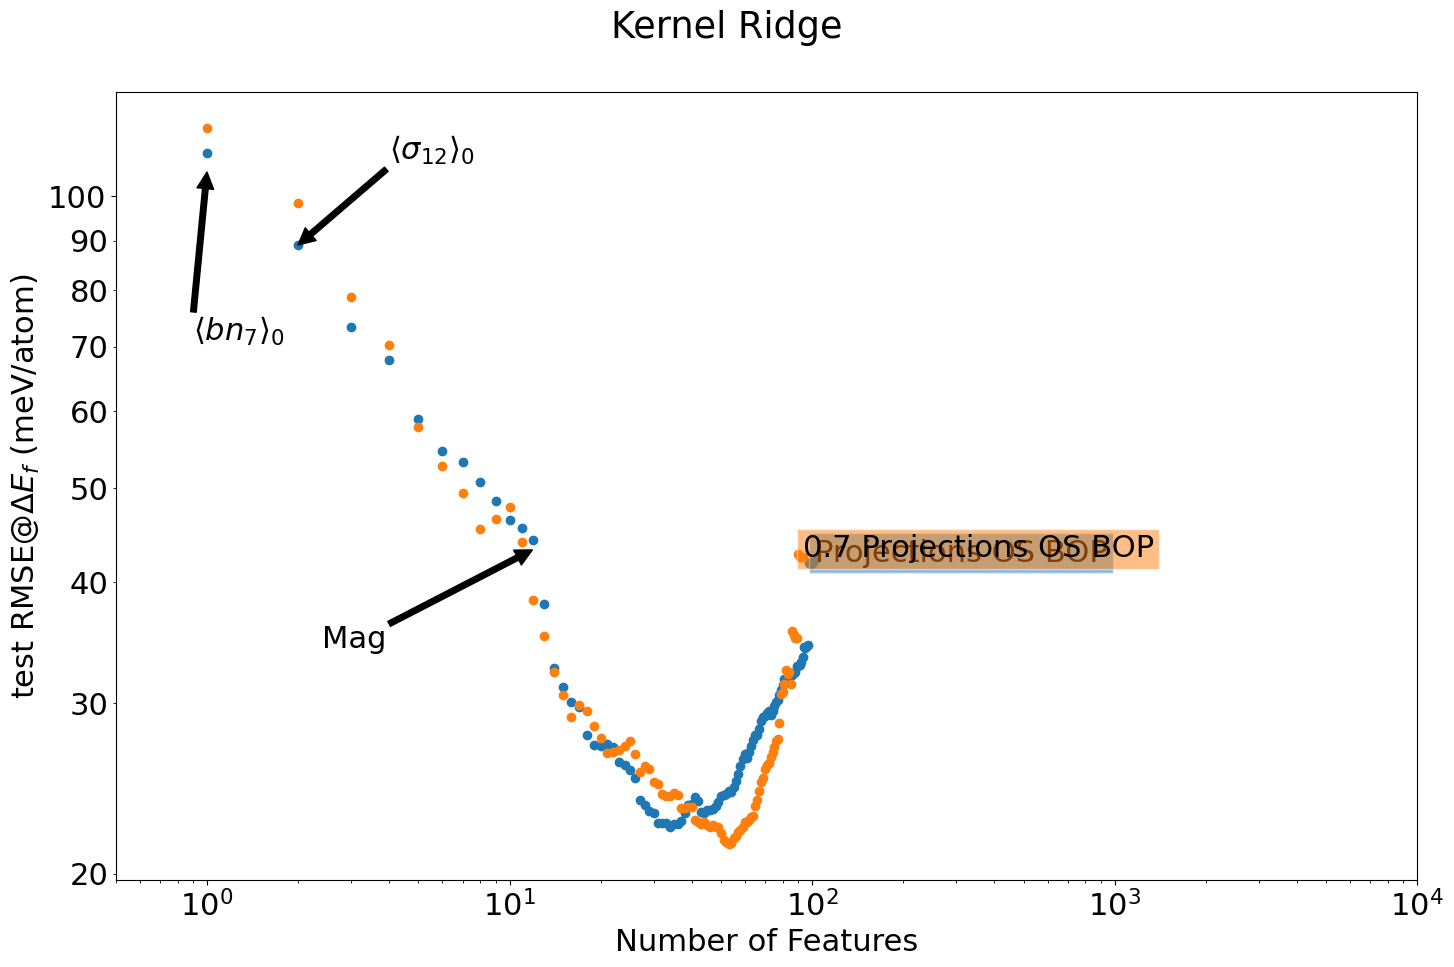

In [41]:
fig

## selections

# Final learn after feature selection 

In [42]:
FCresults.keys()

dict_keys([('Kernel Ridge', 'Projections OS BOP'), ('Kernel Ridge', '0.7 Projections OS BOP'), ('Kernel Ridge', 'Projections sOS BOP')])

In [43]:
MO.load_model_options(ModelName)

In [44]:
OptimalFittedFile = f'{DS.dataset}/results/{DS.dataset}_{ModelName}_OptimalModels_{target_case}_{suffix}.pkl'

In [45]:
OptimalFittedScores = {}
if os.path.exists(OptimalFittedFile):
    OptimalFittedModels = pd.read_pickle(f'Fe-Mo/results/Fe-Mo_Kernel_Ridge_OptimalModels_{target_case}_{suffix}.pkl')
else:
    OptimalFittedModels = {}

In [46]:
folder = StratifiedKFold(shuffle=True, random_state=1503070)
folds_generator = folder.split(DS.samplesplit['train'], DS.StructureNames[DS.samplesplit['train']])
train_folds = list(folds_generator)

In [47]:
selected = {}
for combi in FCresults.keys():
    atmin = FCresults[combi]['test'].argmin()
    selected[combi] = FCresults[combi].index[:atmin]
    if ModelName not in combi:
        continue
    print (combi)
#    OptimalFittedModels[combi]  = copy.deepcopy(Models[ModelName])
#    OptimalFittedModels[combi].set_params(**FCresults[combi].sort_values(by='test').iloc[0].params)
    X = DS.Features[combi[1]][selected[combi]]
    if combi not in OptimalFittedModels:
        OptimalFittedModels[combi] =  GridSearchCV(
        Models[ModelName],
        param_grid=MO.modeloptions[ModelName], 
        cv = train_folds, # test_folds_list, 
        scoring = 'neg_root_mean_squared_error', n_jobs=3, return_train_score=True)
        if 'random' in selected[combi]:
            print(f'random selected in {combi}')
        OptimalFittedModels[combi].fit(X.loc[DS.samplesplit['train']], DS.target[DS.samplesplit['train']])
    OptimalFittedScores[combi] = score_fitted_model(OptimalFittedModels[combi], X.loc[DS.samplesplit['train']], X.loc[DS.samplesplit['test']], DS.target[DS.samplesplit['train']], DS.target[DS.samplesplit['test']] )

('Kernel Ridge', 'Projections OS BOP')
('Kernel Ridge', '0.7 Projections OS BOP')
('Kernel Ridge', 'Projections sOS BOP')


In [48]:
OptimalFittedScores = pd.DataFrame.from_dict(OptimalFittedScores, orient='index')#.sort_values(by='test')
OptimalFittedScores.sort_values(by='test', ascending=False, inplace=True)

In [49]:
#with open(OptimalFittedFile, 'wb') as pkl:
#    pickle.dump(OptimalFittedModels, pkl)
#OptimalFittedScoresFile = f'{DS.dataset}/results/{DS.dataset}_{ModelName}_OptimalScores_{target_case}.pkl'
#with open(OptimalFittedScoresFile, 'wb') as pkl:
#    pickle.dump(OptimalFittedScores, pkl)

In [50]:
OptimalFittedScores

test     train
Kernel Ridge Projections OS BOP      0.037470  0.029817
             0.7 Projections OS BOP  0.029123  0.015023
             Projections sOS BOP     0.023443  0.007886

In [59]:
FCresults[('Kernel Ridge', 'Projections OS BOP')].sort_values(by='test').iloc[0]['test']

0.022353164782457968

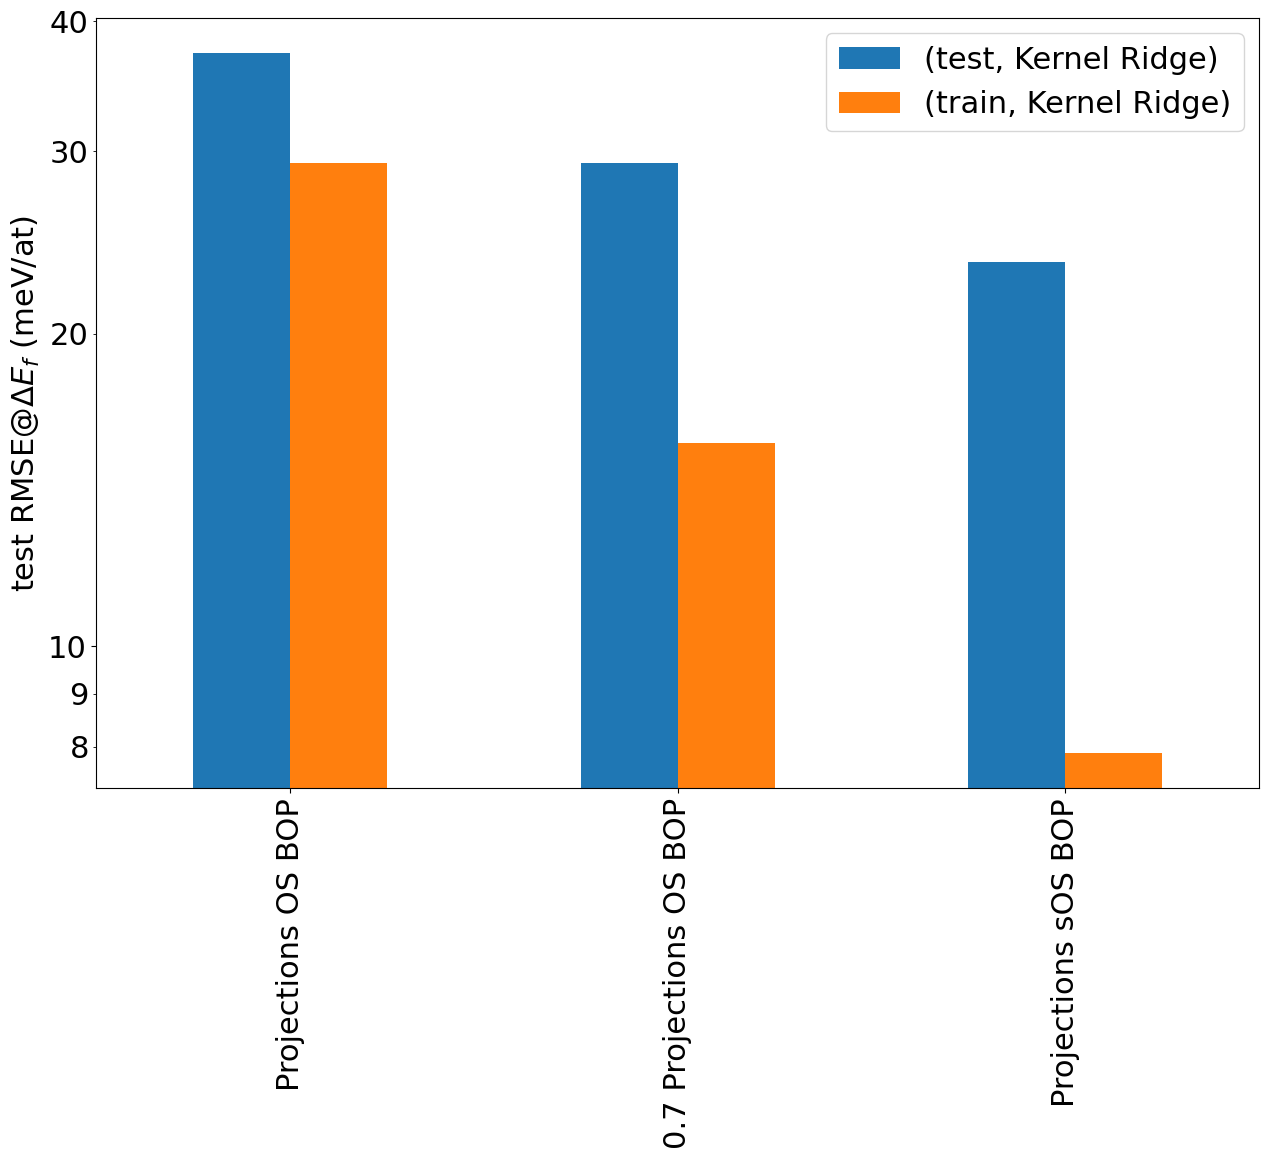

In [52]:
plot_best_scores = SourceFileLoader('plot_best_scores', 'Tools/DatasetTools/MLConveniences.py').load_module().plot_best_scores
ax = plot_best_scores(OptimalFittedScores, ModelName=ModelName)
ax.tick_params(axis='y', which = 'minor')
ax.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax.legend(title='')

In [110]:
combi = ('Kernel Ridge', 'Projections OS BOP')

In [111]:
X = Features[combi[1]][selected[combi]]

In [112]:
OptimalFittedModels[combi].get_params()

{'cv': 5,
 'error_score': nan,
 'estimator__memory': None,
 'estimator__steps': [('scaler', StandardScaler()),
  ('regressor', KernelRidge())],
 'estimator__verbose': False,
 'estimator__scaler': StandardScaler(),
 'estimator__regressor': KernelRidge(),
 'estimator__scaler__copy': True,
 'estimator__scaler__with_mean': True,
 'estimator__scaler__with_std': True,
 'estimator__regressor__alpha': 1,
 'estimator__regressor__coef0': 1,
 'estimator__regressor__degree': 3,
 'estimator__regressor__gamma': None,
 'estimator__regressor__kernel': 'linear',
 'estimator__regressor__kernel_params': None,
 'estimator': Pipeline(steps=[('scaler', StandardScaler()), ('regressor', KernelRidge())]),
 'n_jobs': 3,
 'param_grid': {'regressor__alpha': [1.0, 0.1, 0.01],
  'regressor__kernel': ['polynomial'],
  'regressor__degree': [2, 3, 4, 5],
  'regressor__coef0': [0, 1, 2, 3, 4, 5]},
 'pre_dispatch': '2*n_jobs',
 'refit': True,
 'return_train_score': True,
 'scoring': 'neg_root_mean_squared_error',
 'verb

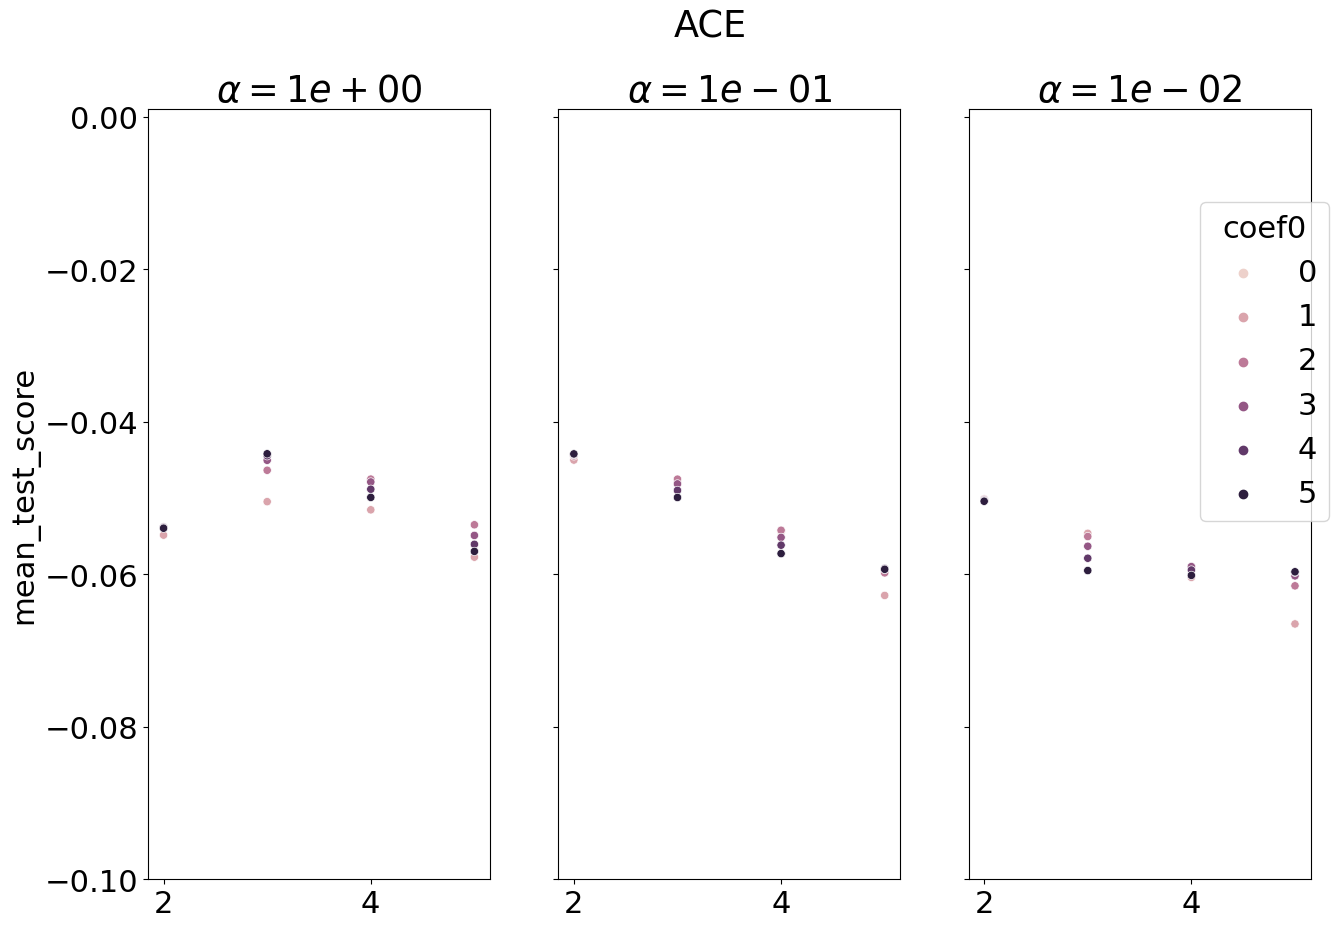

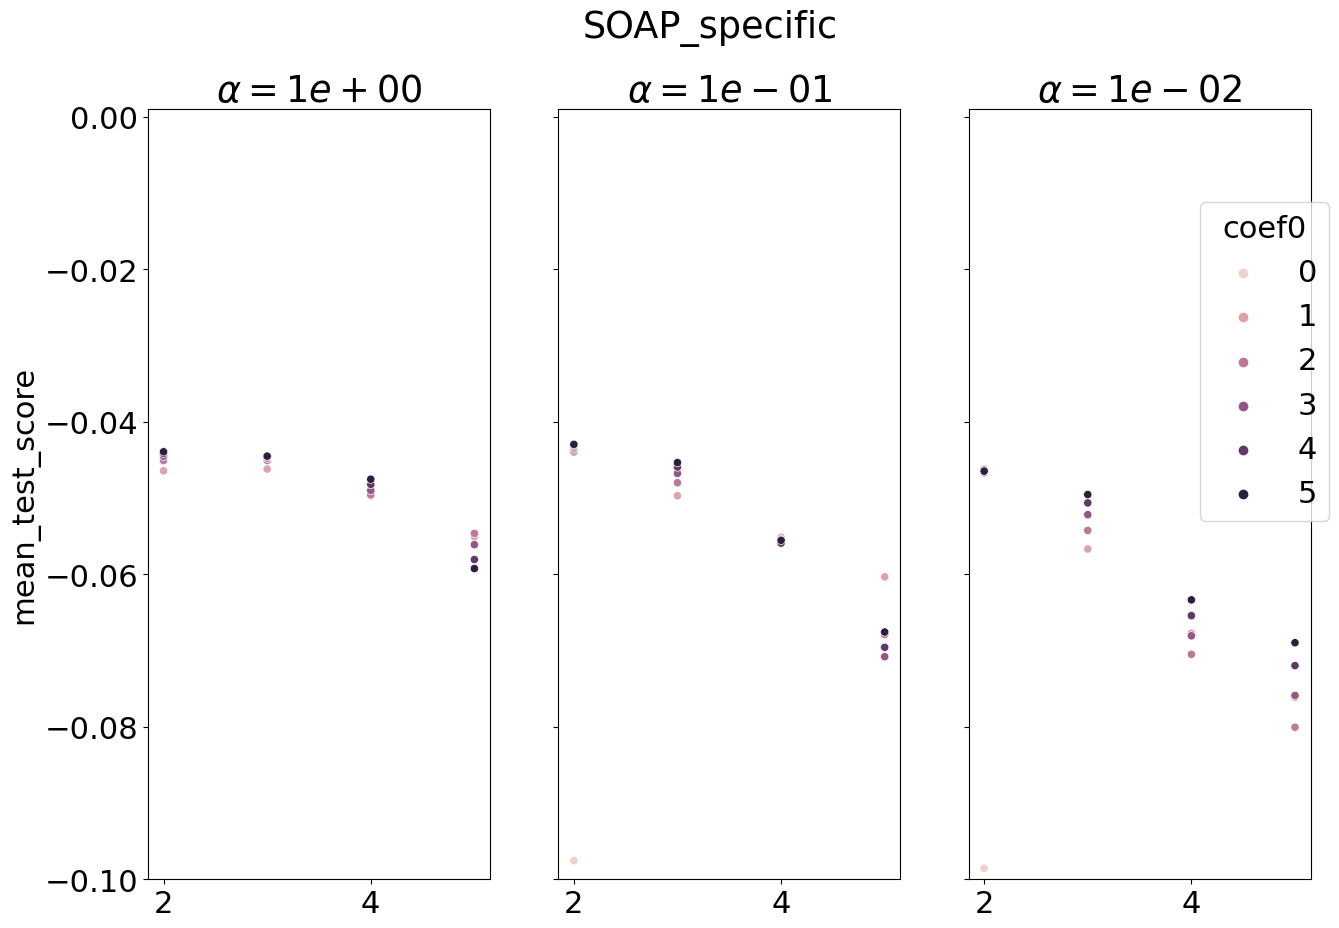

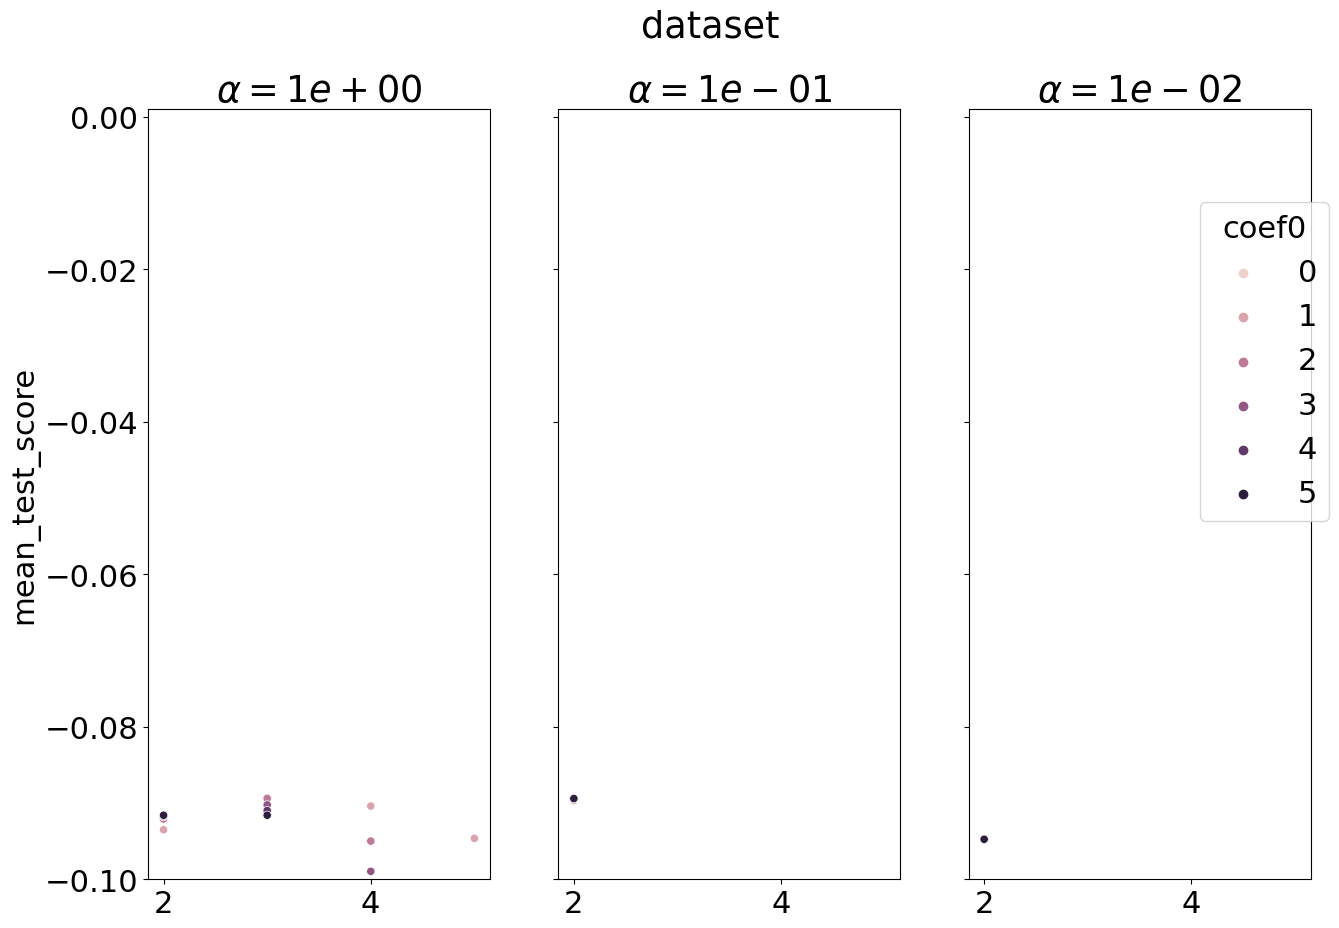

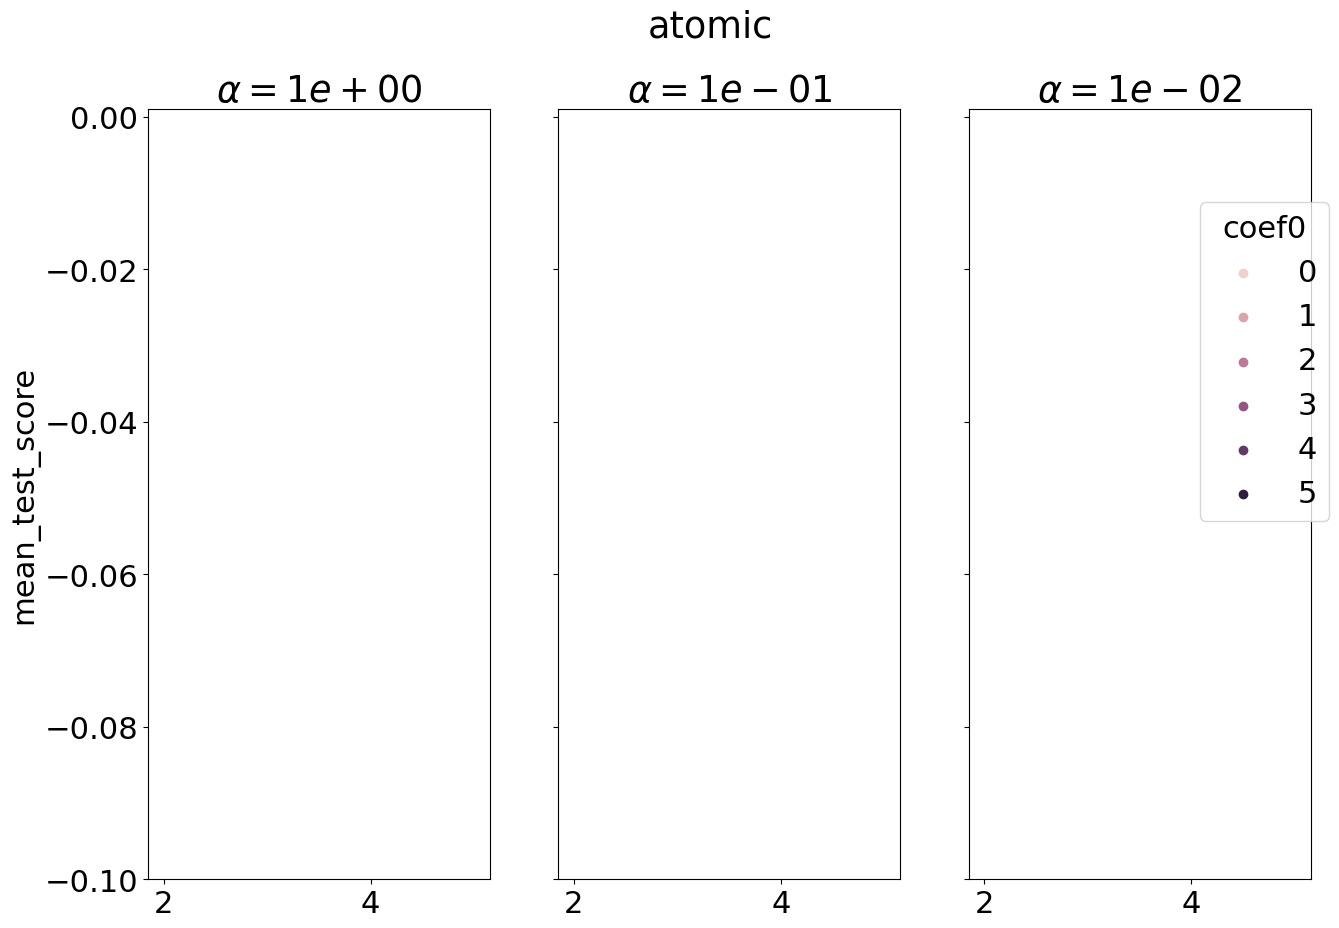

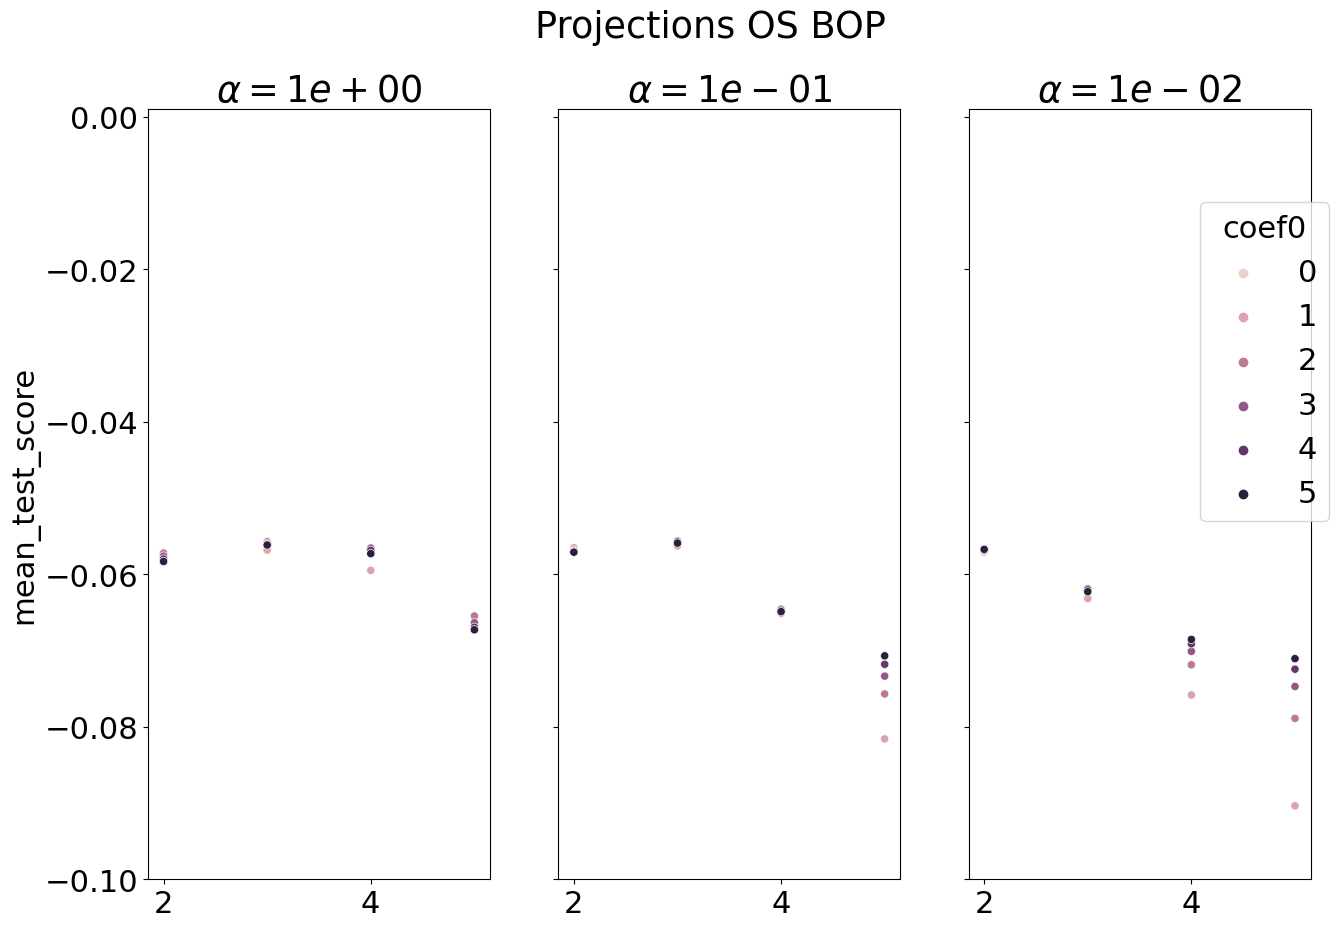

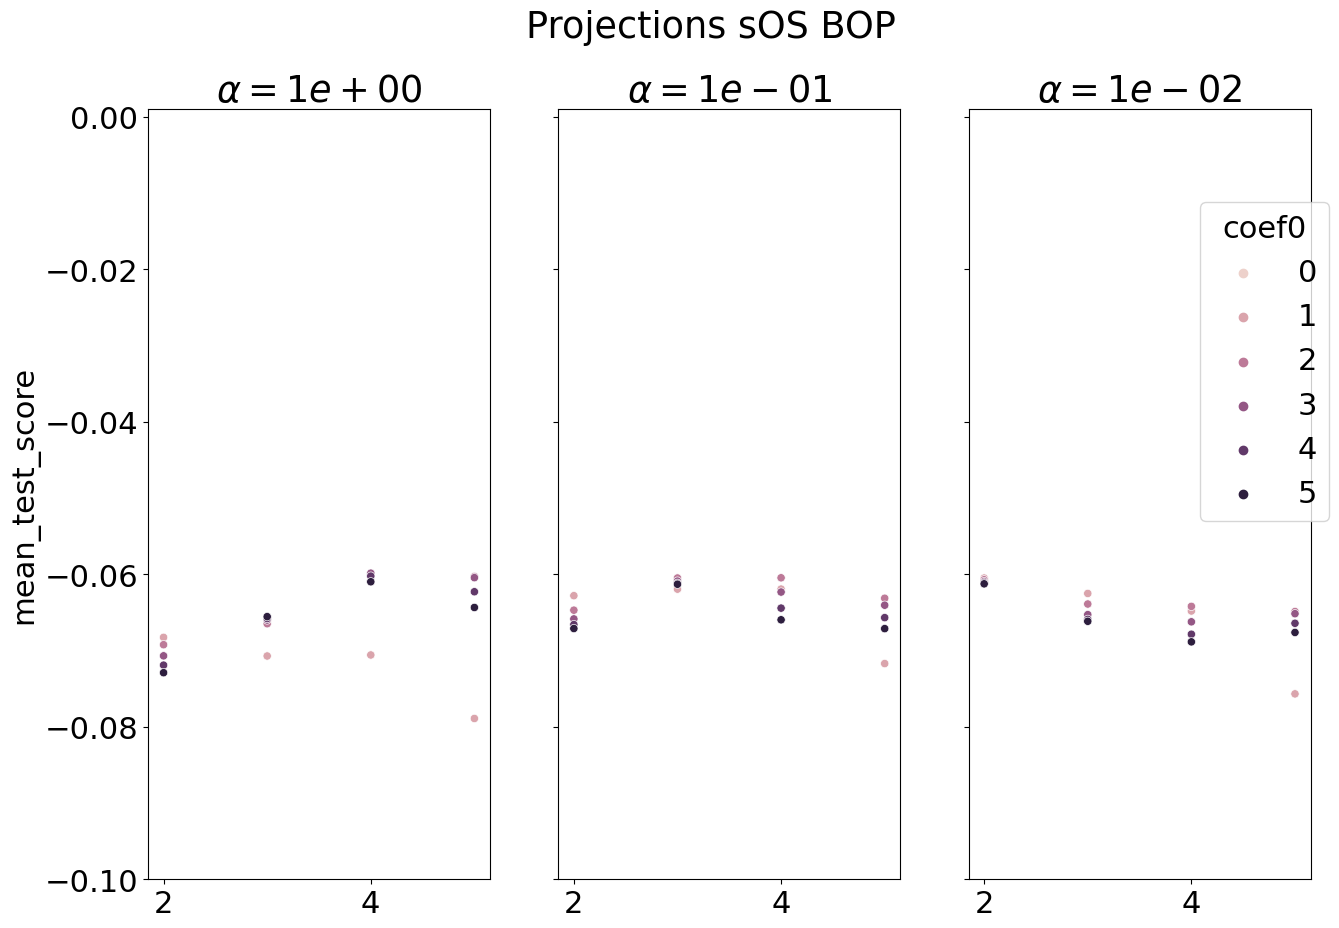

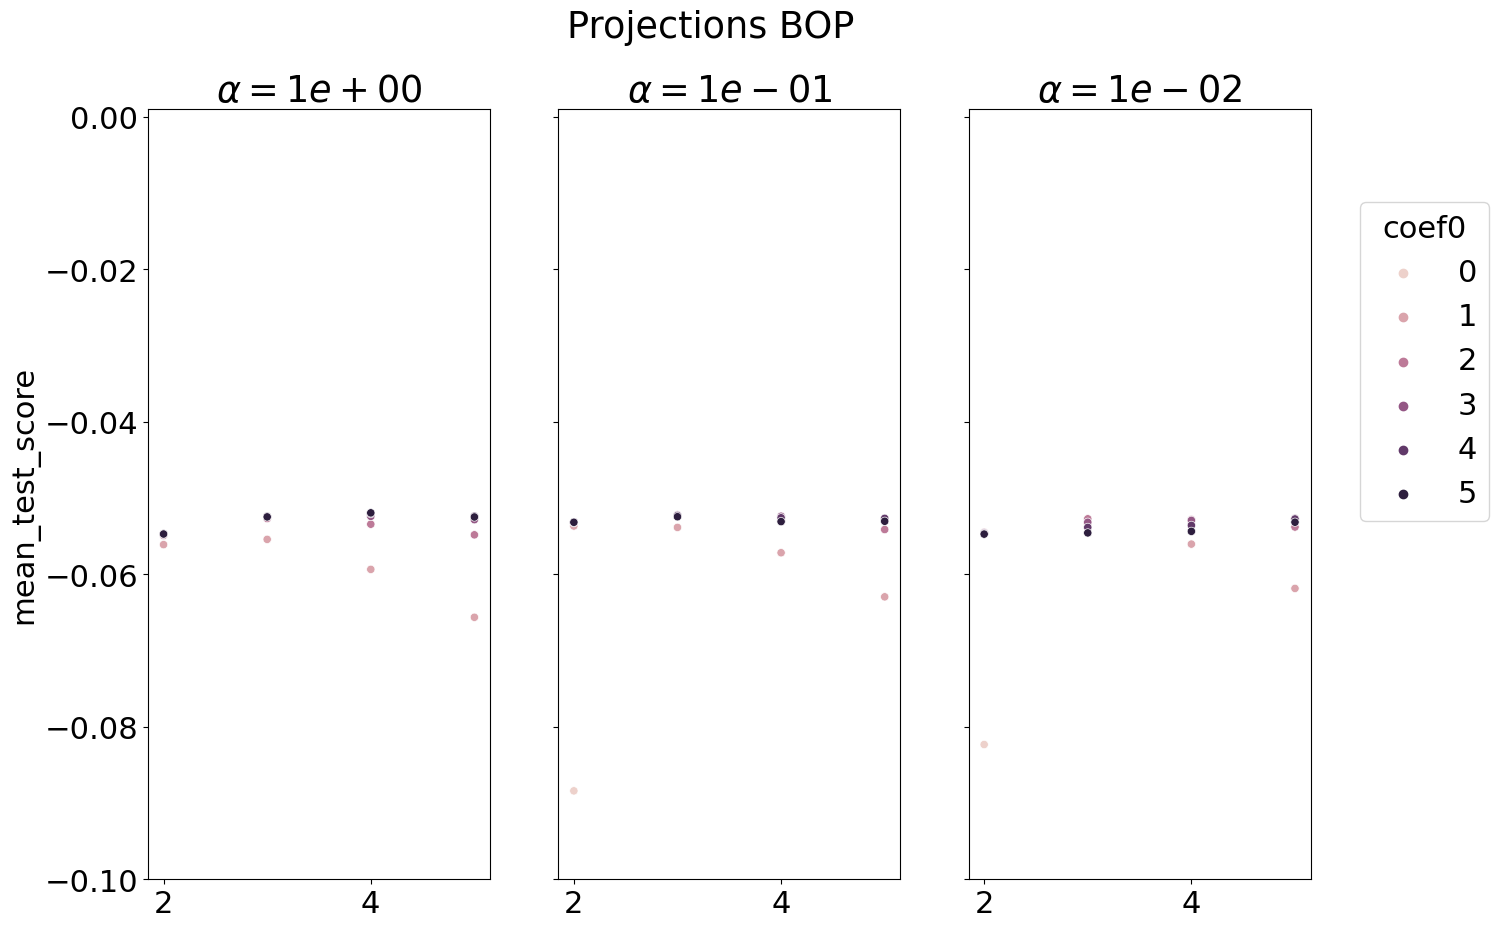

In [113]:

for combi, OptimalModel in OptimalFittedModels.items():
    this_results = pd.DataFrame.from_dict(OptimalModel.cv_results_)
    alphas = this_results['param_regressor__alpha'].unique()
    fig, axes = plt.subplots(1, len(alphas), sharey = True)
    for a, ax  in zip(alphas, axes):
        degree_dep = this_results[(this_results['param_regressor__alpha'] == a) &(this_results['param_regressor__kernel'] == 'polynomial') ]
        sns.scatterplot(data = degree_dep,  x = 'param_regressor__degree', y='mean_test_score', hue='param_regressor__coef0', ax = ax)
        ax.set_xlabel('')
        ax.set_title(fr'$\alpha = {a:.0e}$')
        ax.set_ylim([-0.1,0.001])
        ax.legend().remove()
    axes[-1].legend(bbox_to_anchor=(1.1, 0.9), title='coef0')
    fig.suptitle(combi[1])

In [72]:
FCresults[('Kernel Ridge', 'Projections OS BOP')].sort_values(by='test').iloc[0].params

{'regressor__alpha': 0.1,
 'regressor__coef0': 2,
 'regressor__degree': 3,
 'regressor__kernel': 'polynomial'}

In [73]:
OptimalFittedModels[('Kernel Ridge','Projections OS BOP')].best_params_

{'regressor__alpha': 0.1,
 'regressor__coef0': 3,
 'regressor__degree': 3,
 'regressor__kernel': 'polynomial'}

# fits

In [67]:
ModelName

'Kernel Ridge'

In [68]:
# MO.save_model_options(ModelName, ModelOptions[ModelName])

# MO.modeloptions[ModelName]

samplefolds = list(DS.get_folds())

fittedmodelslocation = os.path.join(DS.resultslocation, f'{ModelName}_{target_case}__FittedCVSearch.pkl')

if os.path.exists(fittedmodelslocation):
    with open(fittedmodelslocation, 'rb') as pkl:
        FittedModels = pickle.load(pkl)
else:
    FittedModels = {}
FittedModels = {}

In [69]:
non_fitted_model = {}

In [70]:
for name, model in Models.items():
    if name not in ModelName:
        print(name)
        continue
    progress = tqdm(Features.items())
    for key, features in progress:  # Features.items():
        progress.set_description(key)
#        if 'BOP' not in key:
#            continue
        if 'no CNAV' in key:
            continue
        if (name, key) in FittedModels.keys():
            continue
        print(key)
        non_fitted_model[(name, key)] = GridSearchCV(
            Models[name],
            MO.modeloptions[name], 
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            verbose = 1,
            return_train_score= True,
        )
        model = copy.deepcopy(non_fitted_model[(name, key)])
        FittedModels[(name, key)] = model.fit(features, DS.target)

with open(fittedmodelslocation, 'wb') as pkl:
    pickle.dump(FittedModels, pkl)

  0%|          | 0/24 [00:00<?, ?it/s]

atomic
Fitting 5 folds for each of 36 candidates, totalling 180 fits
dataset
Fitting 5 folds for each of 36 candidates, totalling 180 fits
SOAP_canonicalFe
Fitting 5 folds for each of 36 candidates, totalling 180 fits
SOAP_canonicalW
Fitting 5 folds for each of 36 candidates, totalling 180 fits


KeyboardInterrupt: 

In [ ]:
best_scores = collect_best_scores(FittedModels)

best_combi = best_scores.idxmin()['test']

best_combi

In [28]:
results = pd.DataFrame.from_dict(FittedModels[best_combi].cv_results_)
results.sort_values(by='mean_test_score', ascending=False, inplace=True)

In [29]:
best_scores.loc[best_combi]

test     4.727365e-02
train    5.838195e-10
Name: (Kernel Ridge, SOAP_specific), dtype: float64

(array([19., 38., 46., 27., 37., 24., 17., 12.,  6.,  5.]),
 array([-0.03847945,  0.03632821,  0.11113587,  0.18594353,  0.26075119,
         0.33555886,  0.41036652,  0.48517418,  0.55998184,  0.6347895 ,
         0.70959716]),
 <BarContainer object of 10 artists>)

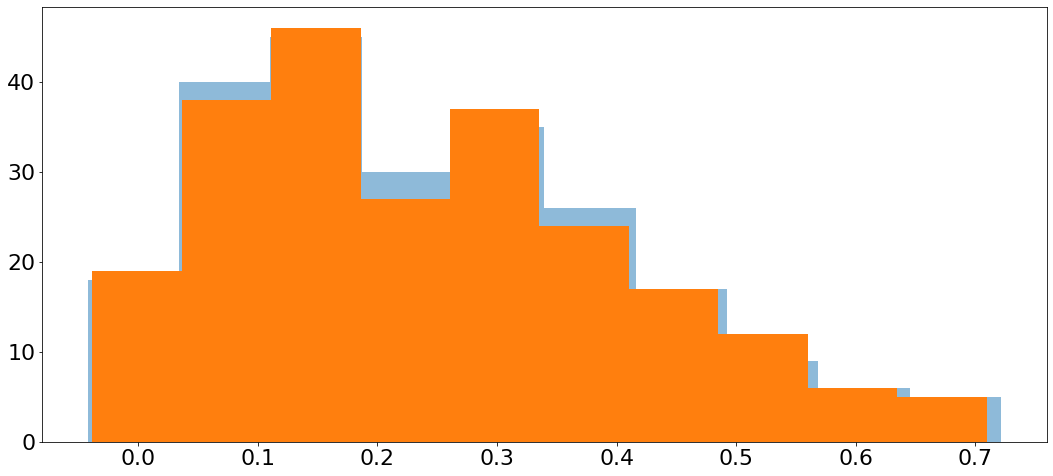

In [30]:
plt.hist(DS.target, alpha=0.5)
plt.hist(FittedModels[best_combi].predict(Features[best_combi[1]]))

for parameters in MO.modeloptions.values():
    for key in parameters.keys():
        print (results.groupby(by='param_'+key)['mean_test_score'].max())

In [31]:
results = pd.DataFrame.from_dict(FittedModels[(ModelName, 'dataset + Projections OS BOP')].cv_results_)  # [['params','mean_test_score']]

In [32]:
results.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_regressor__alpha', 'param_regressor__coef0',
       'param_regressor__degree', 'param_regressor__kernel', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score', 'split0_train_score',
       'split1_train_score', 'split2_train_score', 'split3_train_score',
       'split4_train_score', 'mean_train_score', 'std_train_score'],
      dtype='object')

In [33]:
results.groupby('param_regressor__degree').max()['mean_test_score']

param_regressor__degree
4   -0.056227
5   -0.057071
6   -0.058324
7   -0.059109
Name: mean_test_score, dtype: float64

In [34]:
best_scores

test         train
Kernel Ridge SOAP_specific                  0.047274  5.838195e-10
             Projections OS BOP             0.055119  8.411252e-10
             dataset + Projections OS BOP   0.056227  6.743993e-10
             dataset + Projections BOP      0.059735  5.596963e-10
             dataset + Projections sOS BOP  0.060334  5.755079e-10
             ACE_CNAV                       0.061004  2.124607e-09
             ACE                            0.064605  1.590950e-09
             dataset + Canonical BOP        0.065015  4.793931e-08
             Projections BOP                0.066394  6.962016e-10
             Projections sOS BOP            0.066613  7.351387e-10
             Canonical BOP                  0.081419  5.726531e-04
             dataset                        0.083179  4.444176e-10
             SOAP_canonicalFe               0.165183  3.374721e-02
             SOAP_canonicalW                0.165183  3.374721e-02
             atomic                         0.178827  3.856865e-02
             Pyscal                         0.183410  1.014553e-01

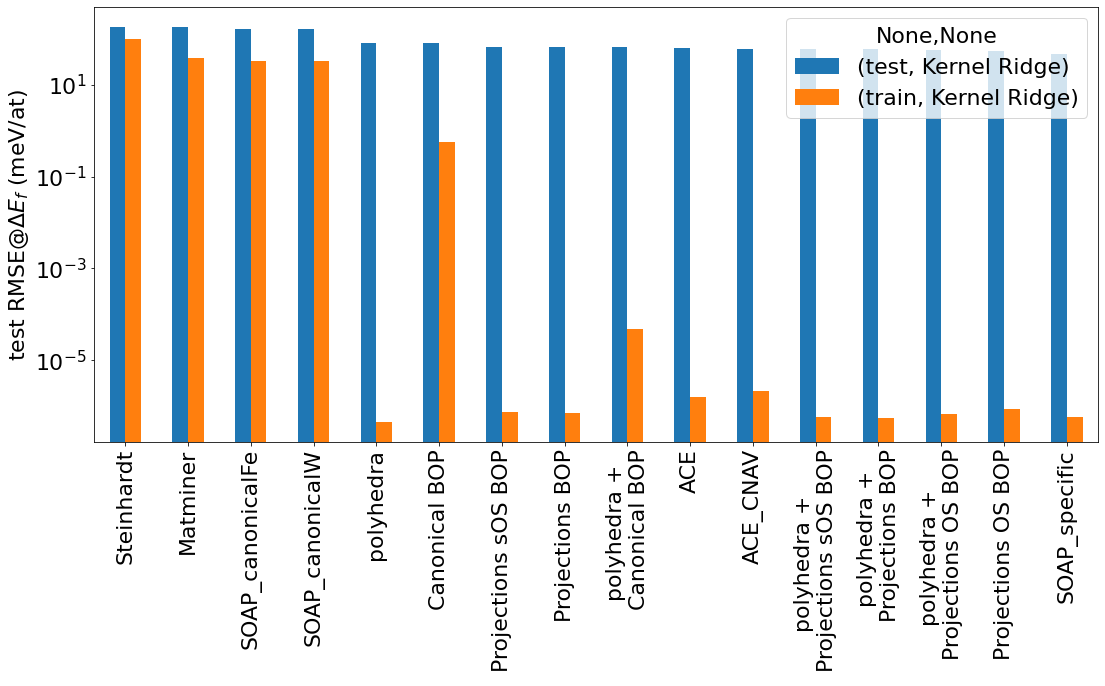

In [35]:
ax = plot_best_scores(best_scores, ModelName=ModelName)

# Recursivity

In [36]:
Tester = DatasetTester()

In [37]:
from importlib.machinery import SourceFileLoader
Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
# from Tools.DatasetTools.DatasetOperator import Dataset
# DS = SourceFileLoader('DS', 'Tools/DatasetTools/DatasetOperator.py').load_module().Dataset('Fe-Mo')
# Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
# samplesplit = DS.get_samplesplit()

['', '/home/storage/fortimtb/DatasetsML', '/home/storage/fortimtb/DatasetsML', '/scratch/AnacondaEnvironments/ml_datasets/lib/python39.zip', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/lib-dynload', '', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/ipython_genutils-0.2.0-py3.9.egg', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/webencodings-0.5.1-py3.9.egg', '/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/maxvolpy-0.3.8-py3.9-linux-x86_64.egg']


In [38]:
import copy

In [39]:
RecursivityModels = copy.deepcopy(FittedModels)

In [40]:
test_scores = Tester.make_recursivity_anbn(DS, RecursivityModels, {'includemag': False})

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

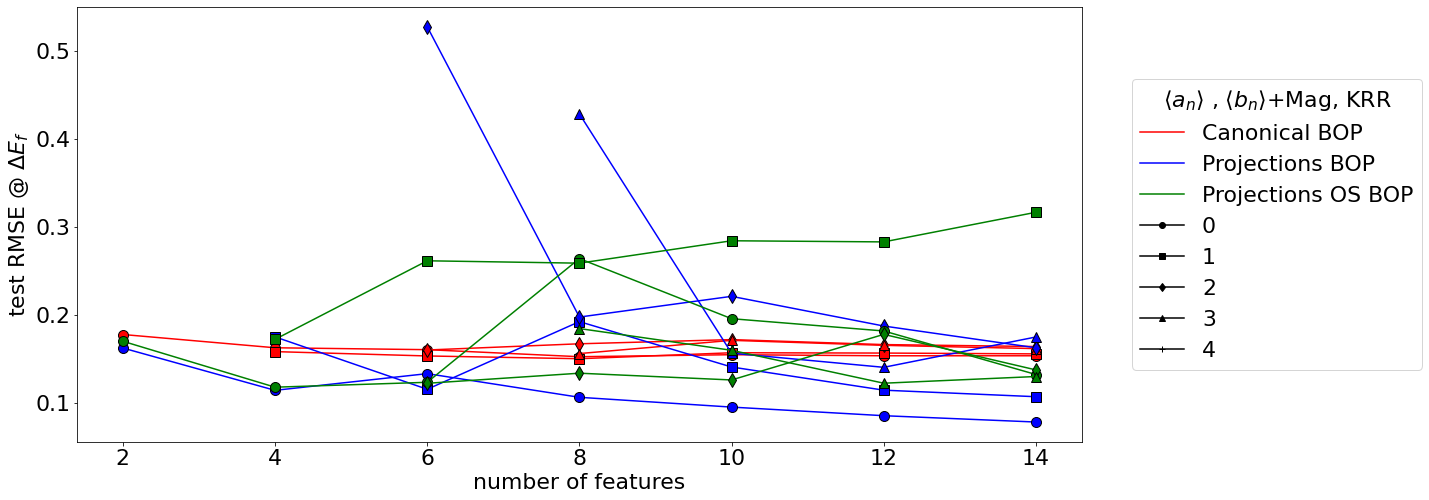

In [41]:
Tester.plot_recursivity_curve(test_scores, ModelName, )

fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{ModelName}_recursivity_anbn.pdf', bbox_inches='tight')

# Fits on reduced features 

In [42]:
ReducedFittedModels = {}

In [43]:
Reduced_features_fitting_location = os.path.join(DS.resultslocation, f'ReducedFeaturesCVSearch_{target_case}.pkl')

In [44]:
if os.path.exists(Reduced_features_fitting_location):
    with open(Reduced_features_fitting_location, 'rb') as pkl:
        ReducedFittedModels = pickle.load(pkl)

In [45]:
MO.modeloptions

{'Kernel Ridge': {'regressor__alpha': [0.1, 0.01, 0.001, 0.0001],
  'regressor__kernel': ['rbf', 'polynomial'],
  'regressor__degree': [4, 5, 6, 7],
  'regressor__coef0': [0, 1, 10]}}

In [46]:
maxorders = [8, 10, 12, 14, 16]
for name, model in Models.items():
    if name != ModelName:
        continue
    progress = tqdm(product(Features.items(), maxorders), total=len(maxorders)*len(Features))
    for (key, features), maxorder in progress:  # maxorder in range(4,9):
        progress.set_description(name+', '+key+', '+str(maxorder)+':  ')
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if 'no CNAV' in key:
            continue
        if 'BOP' not in key:
            continue
        if 'Projections' not in key:
            continue
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if maxorder < 10:
            regexstr = f'^(?!.*_[{maxorder}-9]_.*|.*_1[0-9]_.*)'
        else:
            regexstr = f'^(?!.*_1[{maxorder - 10}-9]_.*)'
#        for key, features in progress: #Features.items():
        model = GridSearchCV(
            Models[name],
            MO.modeloptions[name], 
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            return_train_score= True,
        )
        if 'BOP' in key:
            reducedfeatures = features.filter(regex=regexstr)
        else:
            reducedfeatures = features
        ReducedFittedModels[(name, key, maxorder)] = model.fit(reducedfeatures, DS.target)

  0%|          | 0/120 [00:00<?, ?it/s]

In [47]:
with open(Reduced_features_fitting_location, 'wb') as pkl:
    pickle.dump(ReducedFittedModels, pkl)

In [48]:
somecombi = (ModelName, 'Projections BOP')

In [49]:
features_in_reduced = pd.Index(ReducedFittedModels[somecombi+(16,)].feature_names_in_)

In [50]:
features_in = pd.Index(FittedModels[somecombi].feature_names_in_)

In [51]:
features_in.difference(features_in_reduced)

Index([], dtype='object')

In [52]:
best_scores_reduced = collect_best_scores(ReducedFittedModels)

In [53]:
model = best_scores_reduced.index.get_level_values(0)

In [54]:
test_scores_vs_max = best_scores_reduced.unstack().transpose().loc['test'].dropna(axis=1)

In [55]:
test_scores_vs_max[ModelName]

,Projections BOP,Projections OS BOP,Projections sOS BOP,dataset + Projections BOP,dataset + Projections OS BOP,dataset + Projections sOS BOP
8,0.047882,0.040666,0.048468,0.047663,0.042411,0.047647
10,0.046306,0.040882,0.046365,0.046480,0.042061,0.046139
12,0.045612,0.040496,0.046049,0.045990,0.041931,0.046091
14,0.045961,0.040655,0.046493,0.046374,0.042176,0.046555
16,0.046835,0.041659,0.047747,0.047285,0.042819,0.047858


In [56]:
full_model_test_scores = best_scores.unstack().transpose().loc['test']

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


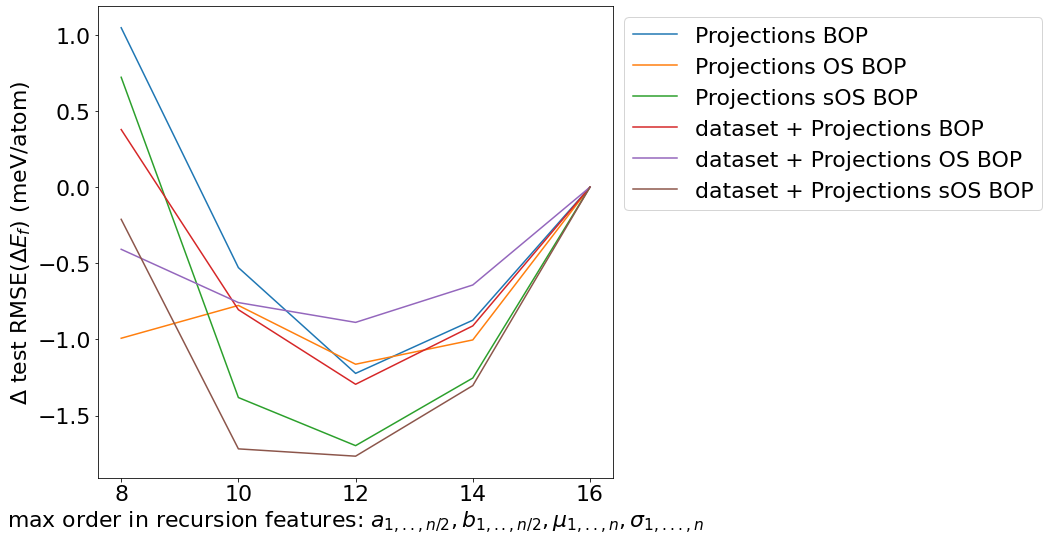

In [57]:
fig, ax = plt.subplots(figsize=(15, 8))
for combi in test_scores_vs_max.columns:
#    if 'BOP' not in combi[1]:
#        continue
#    if 'Canonical' in combi[1]:
#        continue
#    if 'dataset' not in combi[1]:
#        continue
    drmse = (test_scores_vs_max[combi].values - test_scores_vs_max[combi].values[-1])*1000  # - full_model_test_scores[combi[0]][combi[1]]*1000
    l = ax.plot(test_scores_vs_max[combi].index, drmse, label=combi[1])[0]
#    ax.axhline(full_model_test_scores[combi[0]][combi[1]]*1000,ls='--', color=l.get_color())
ax.legend(bbox_to_anchor = (1, 1))
ax.set_ylabel(r'$\Delta$ test RMSE($\Delta E_f$) (meV/atom)')
ax.set_xlabel(r'max order in recursion features: $a_{1,..,n/2}, b_{1,..,n/2}, \mu_{1,..,n}, \sigma_{1,...,n}$')
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_full_recursivity_{target_case}.eps'))

# Prediction line 

In [84]:
Prediction = {}
for combi, model in OptimalFittedModels.items():
    atmin = FCresults[combi]['test'].argmin()
    selected = FCresults[combi].index[:atmin]
    X = DS.Features[combi[1]][selected]
    Prediction[combi] = model.predict(X)

In [85]:
#iwanttoplot = {'atomic':'Matminer',
iwanttoplot = {'Canonical BOP': 'Canonical BOP', 'Projections OS BOP':'Projections OS BOP'}
#iwanttoplot = {'dataset': 'dataset', 'Projections OS BOP':'Projections OS BOP'}

Canonical BOP Canonical BOP
Projections OS BOP Projections OS BOP


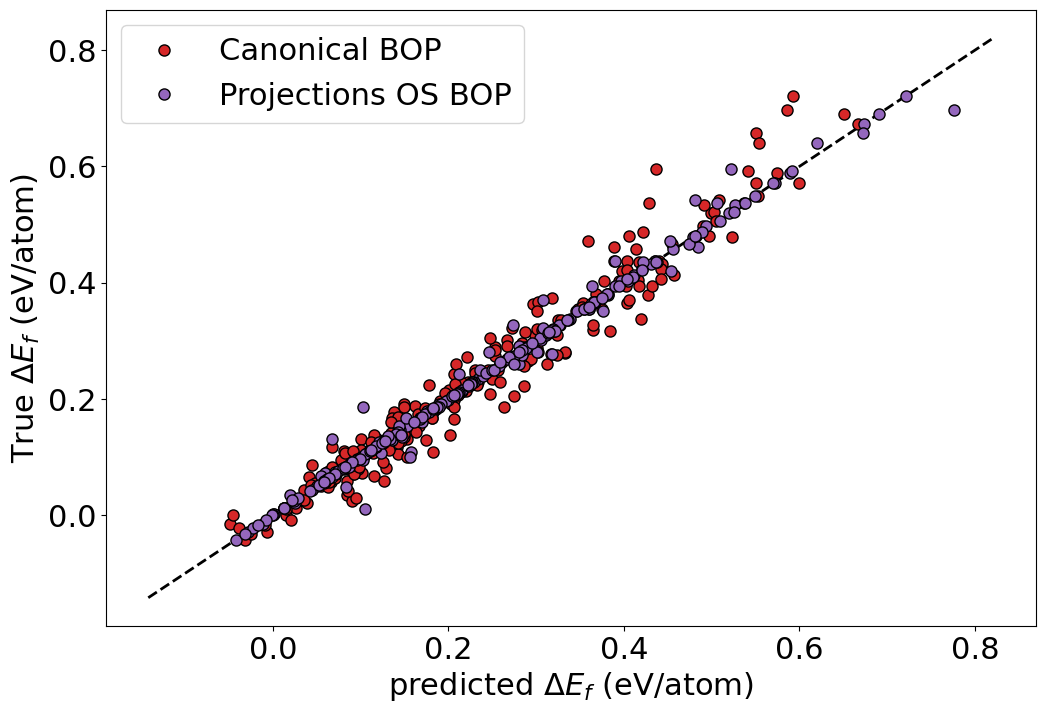

In [86]:
x_y = np.linspace(DS.target.min()-0.1, DS.target.max()+0.1, 2)
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(x_y, x_y, '--k', lw=2)
for name, legend in iwanttoplot.items():
    print(name, legend)
    legend = legend.replace('dataset', 'polyhedra')
    combi = (ModelName, name)
    if combi not in Prediction.keys():
        print(f'{combi} has not been processed yet')
        continue
    ax.plot(Prediction[combi], DS.target, 'o', markersize=8, markeredgecolor='k', color=colors[name], label=legend)
#    sns.scatterplot(Prediction[name], DS.target,ax=ax) #, markersize=8, markeredgecolor='k',  color = color, label=legend)
ax.set_xlabel(r'predicted $\Delta E_f$ (eV/atom)')
ax.set_ylabel(r'True $\Delta E_f$ (eV/atom)')
ax.legend()
fig.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_{ModelName}_predictionline_{target_case}.pdf'))

# Feature Importances 

In [87]:
importances = {}
for combi, estimator in OptimalFittedModels.items():
    print(combi[1])
    atmin = FCresults[combi]['test'].argmin()
    selected = FCresults[combi].index[:atmin]
    if 'random' in selected:
        print(f'random selected in {combi}')
    X = DS.Features[combi[1]][selected]
    allimportances = get_importances(estimator , X,  DS.target)
    importances[combi] =allimportances #  [allimportances['importances_mean']>=allimportances['importances_mean']['random']]

SOAP_specific
random selected in ('Kernel Ridge', 'SOAP_specific')
ACE_CNAV
Canonical BOP
Projections OS BOP
ACE


In [88]:
for (modelname, name),timportances in importances.items():
    timportances.sort_values(by='importances_mean', inplace=True, ascending=False)

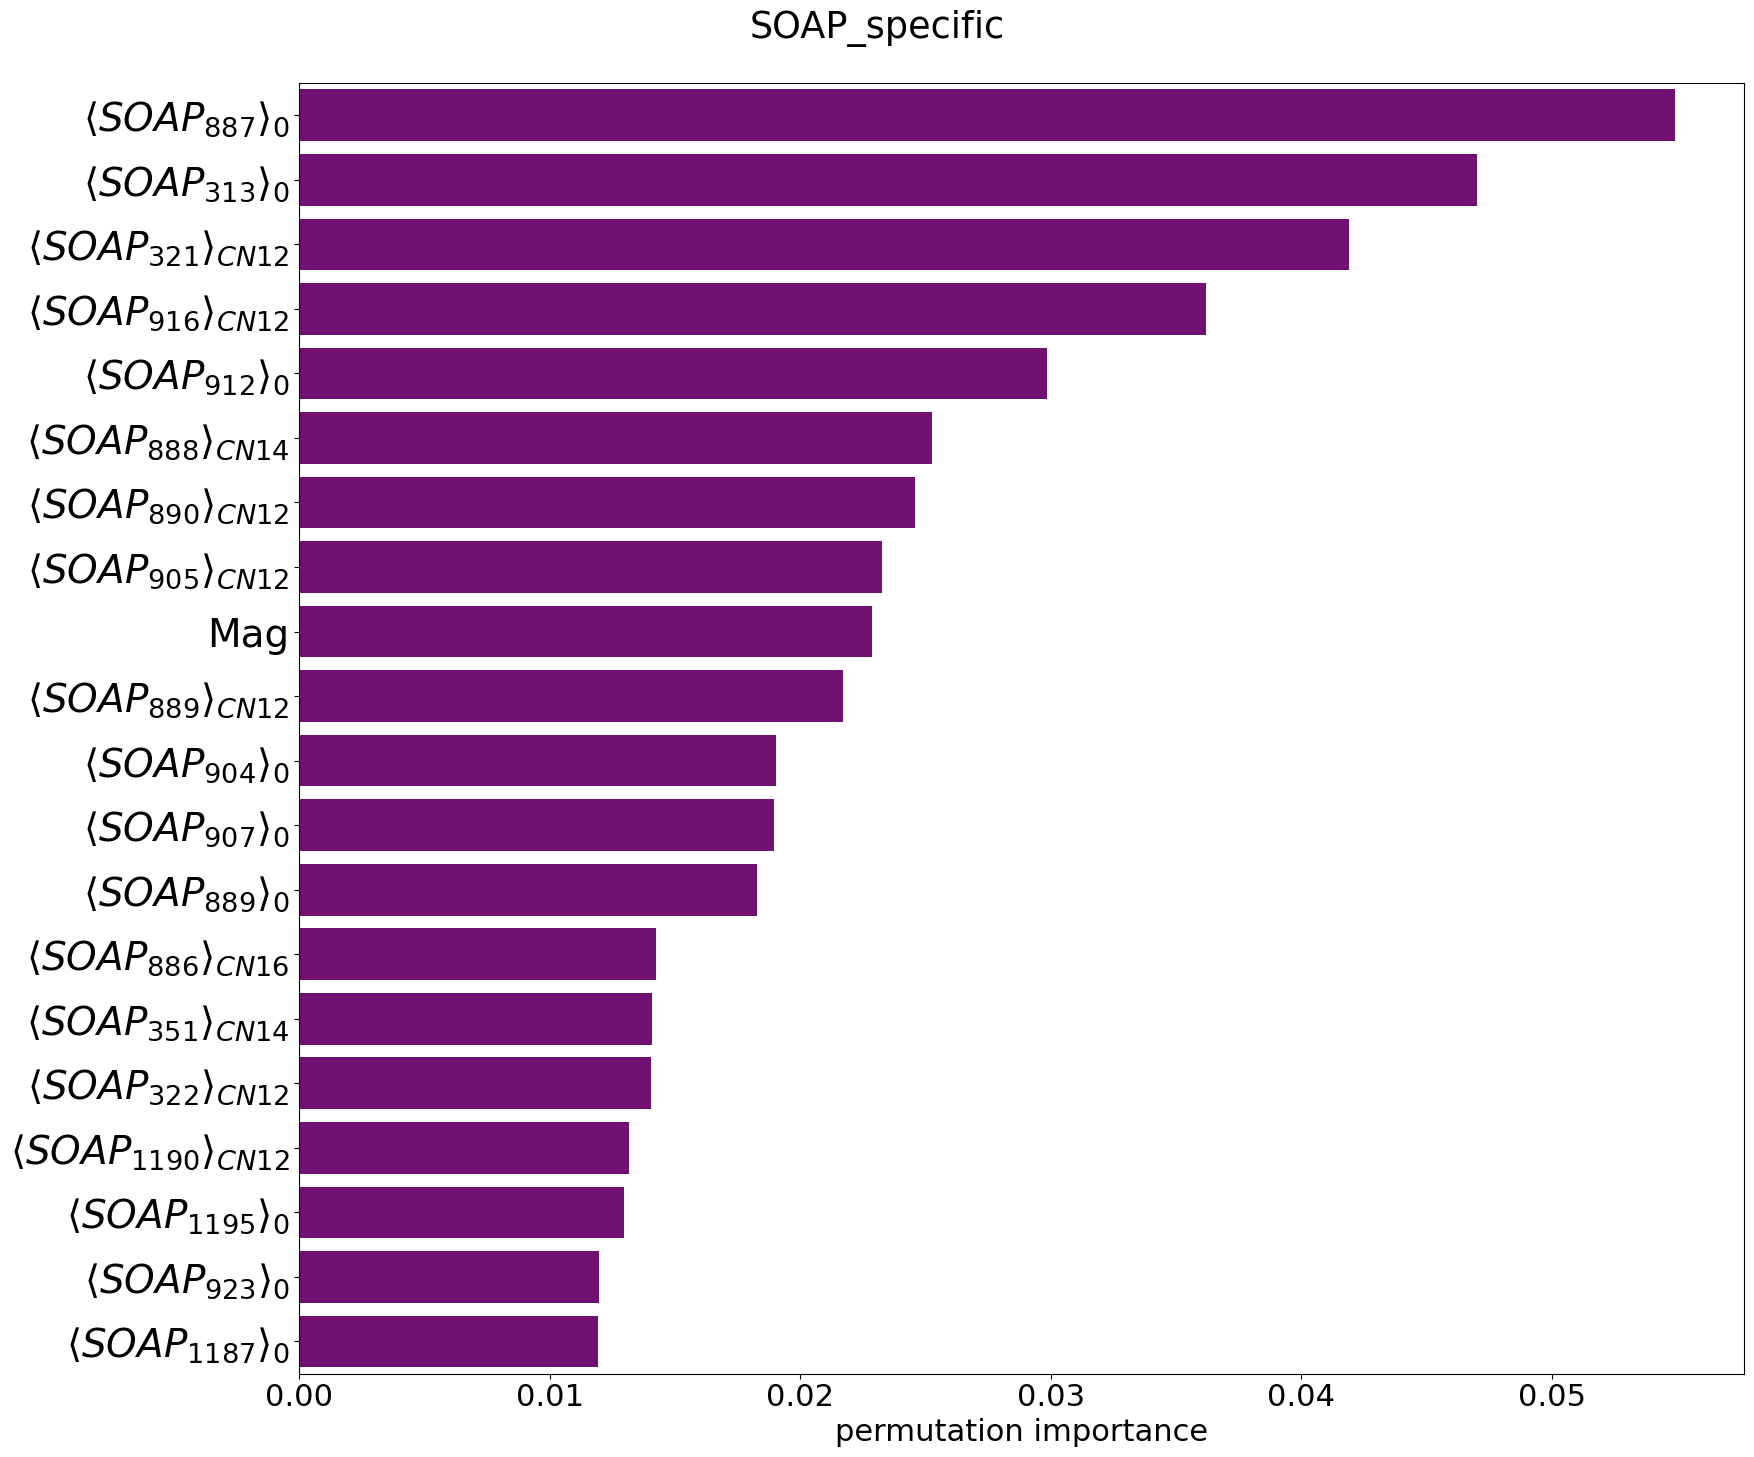

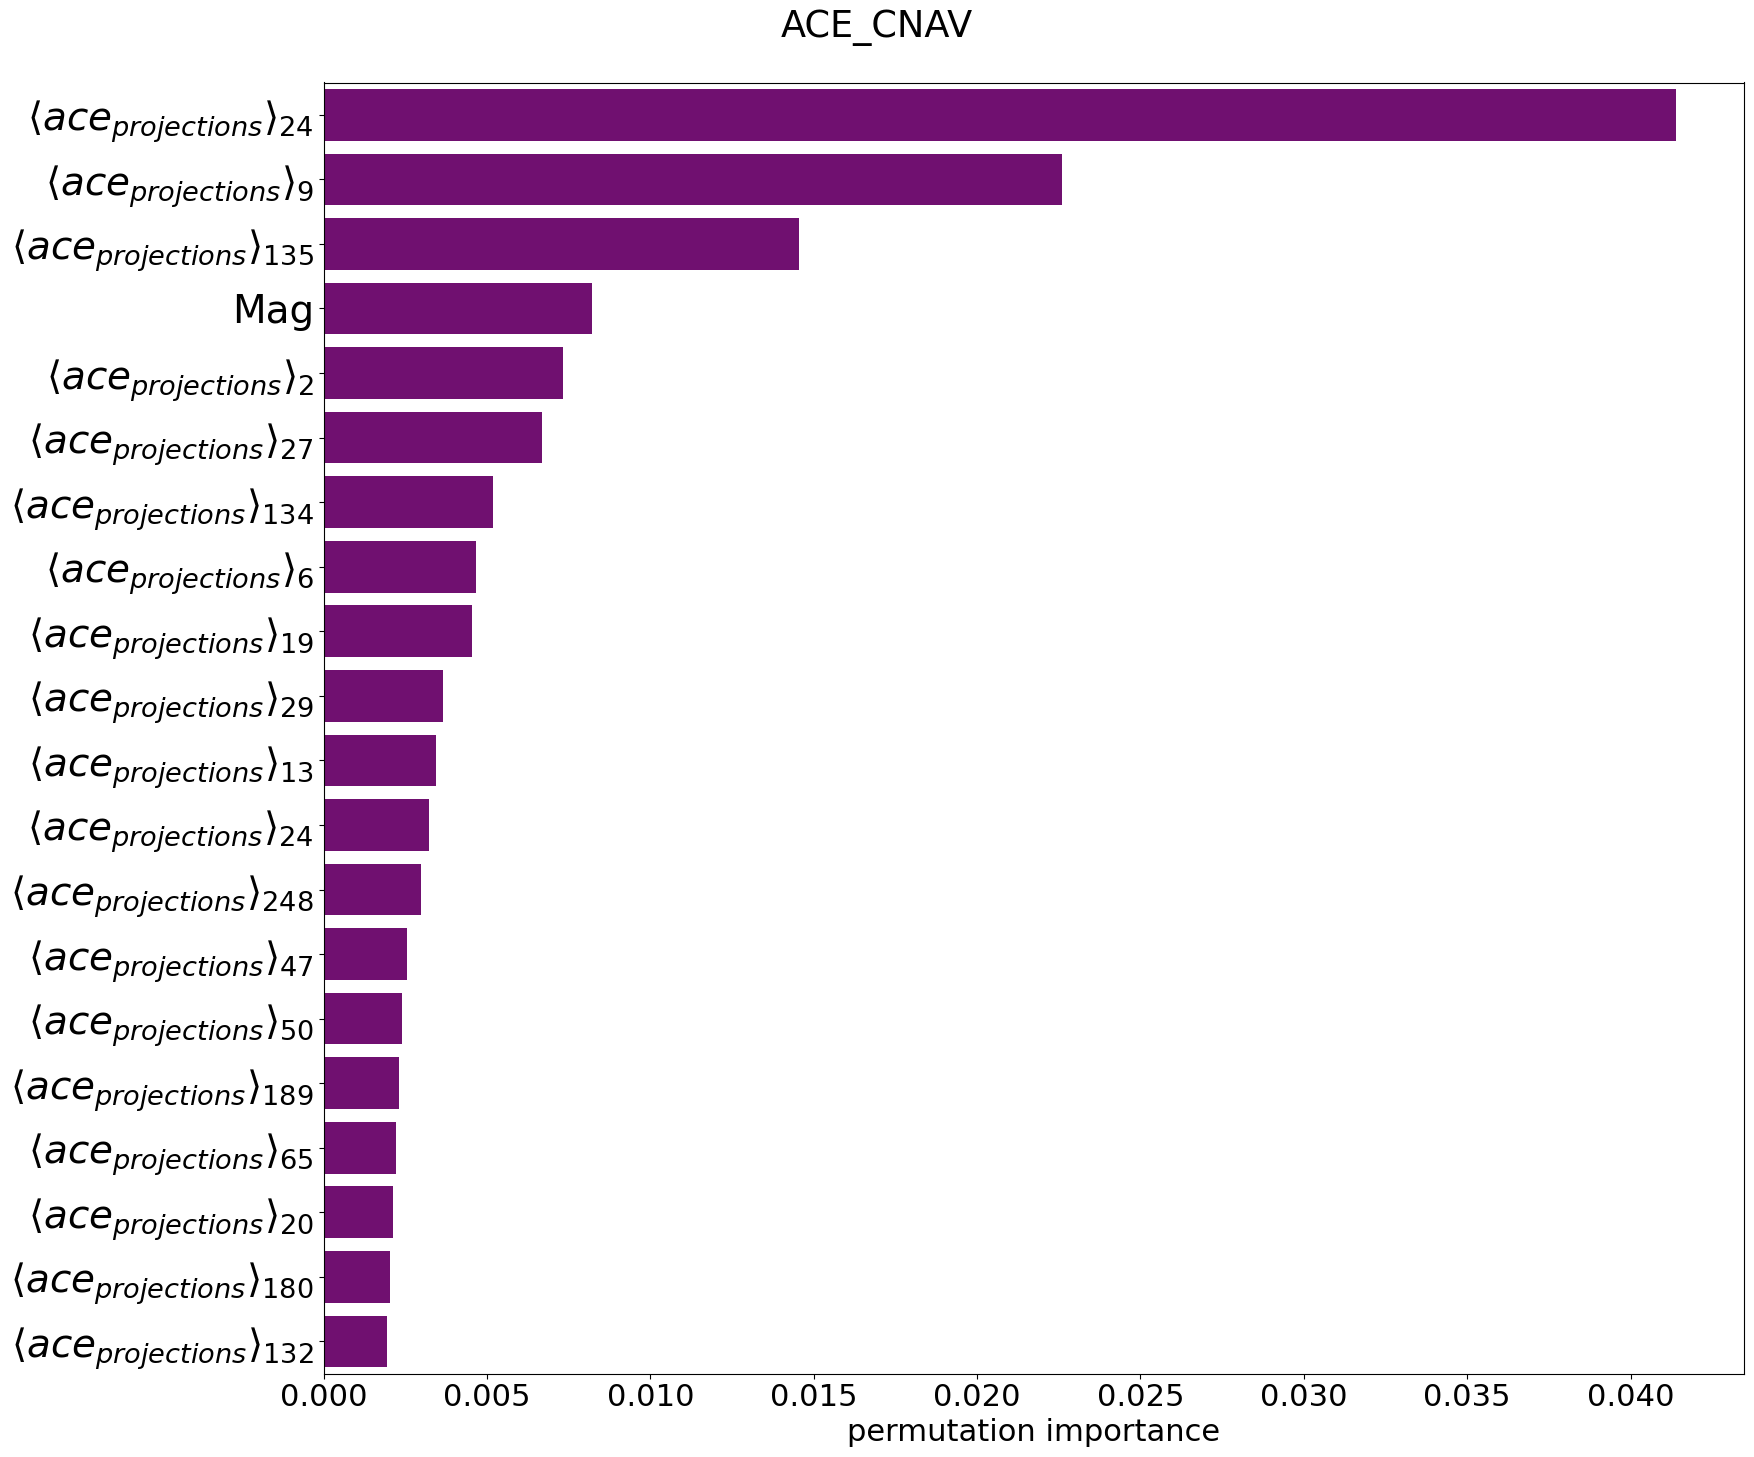

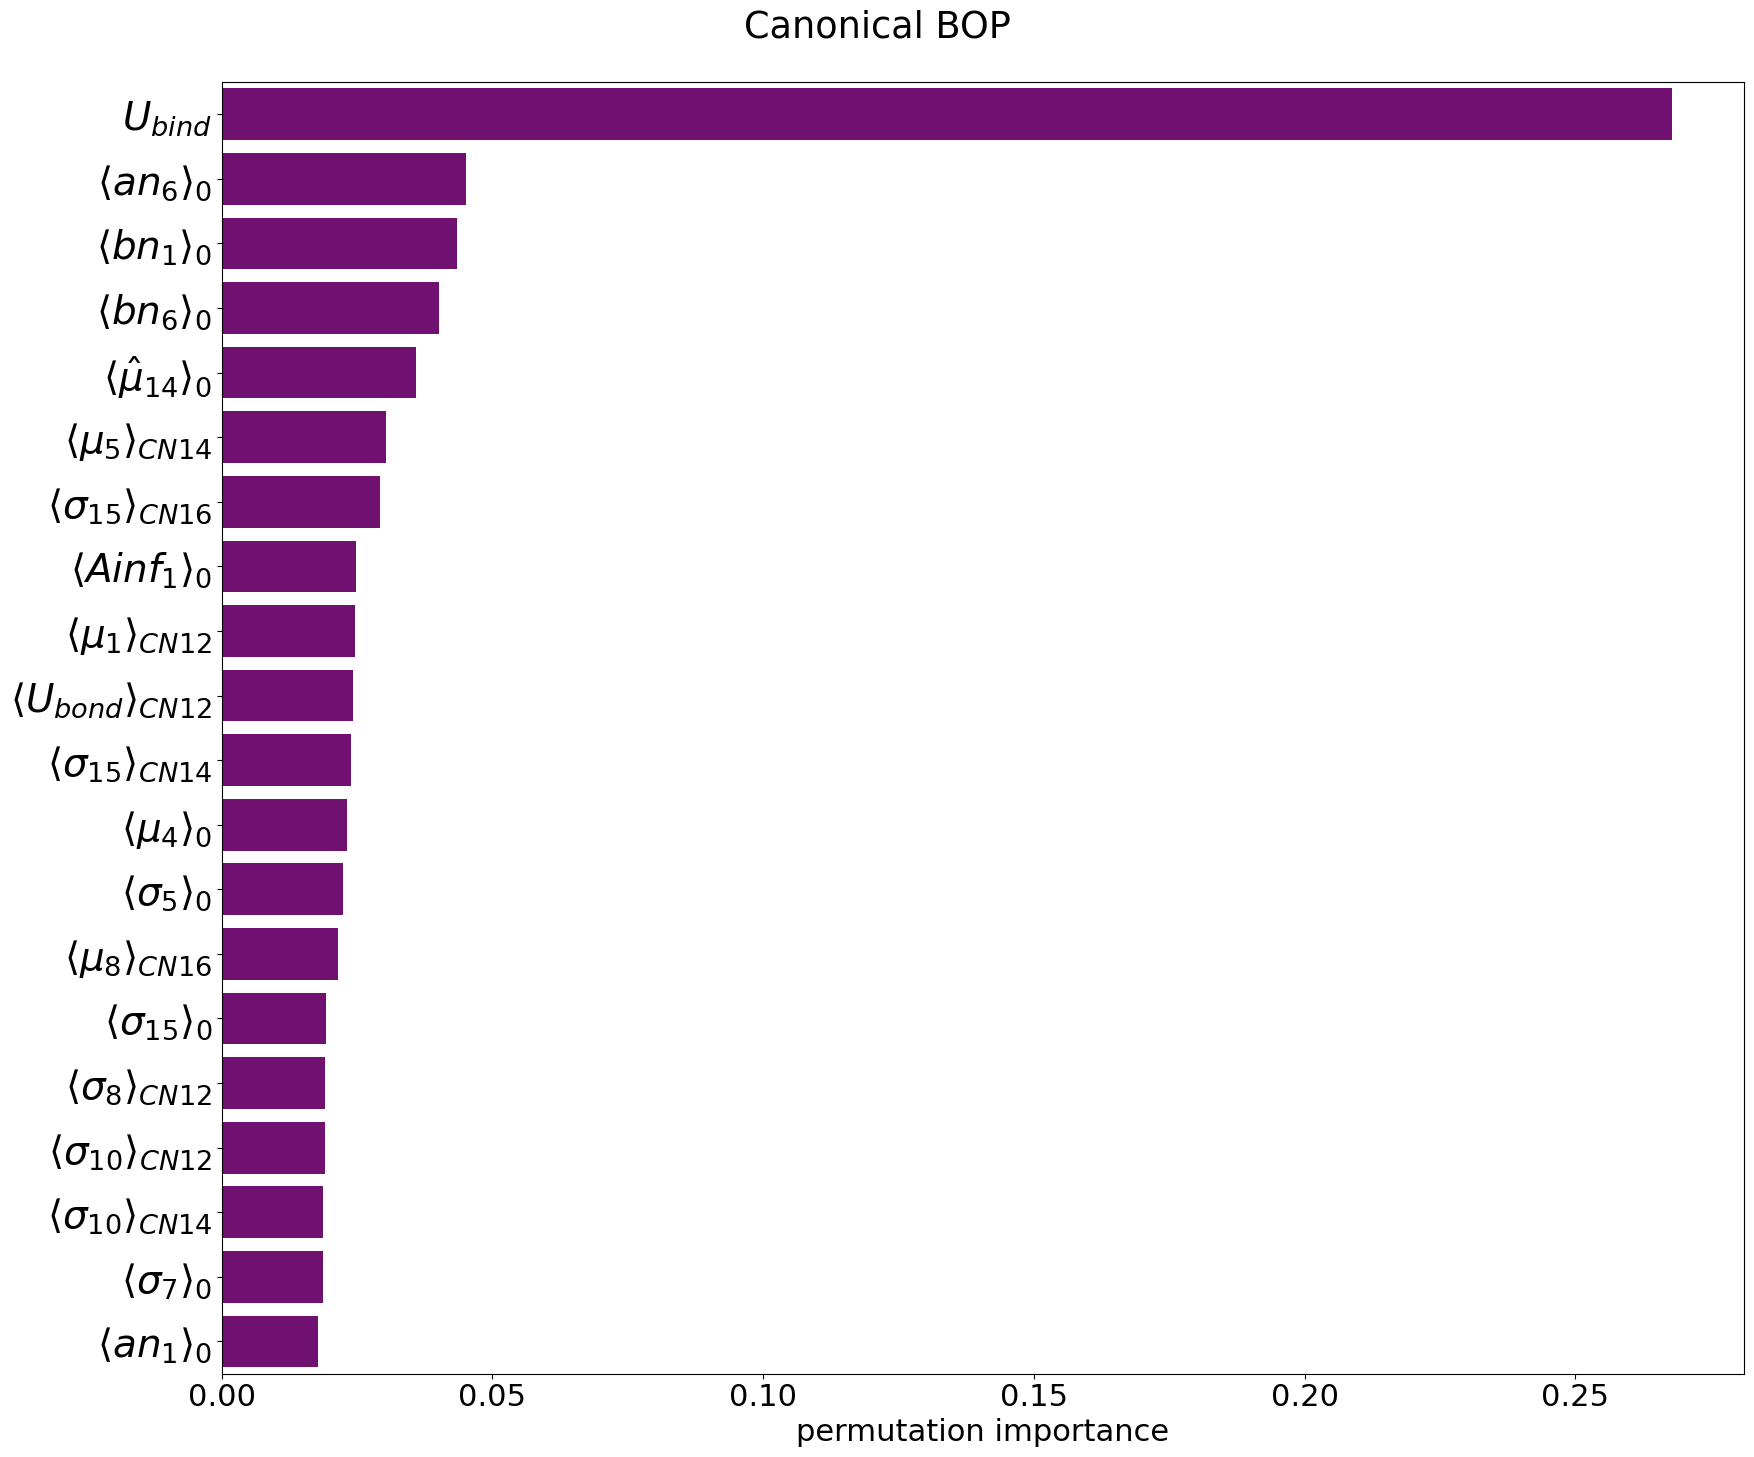

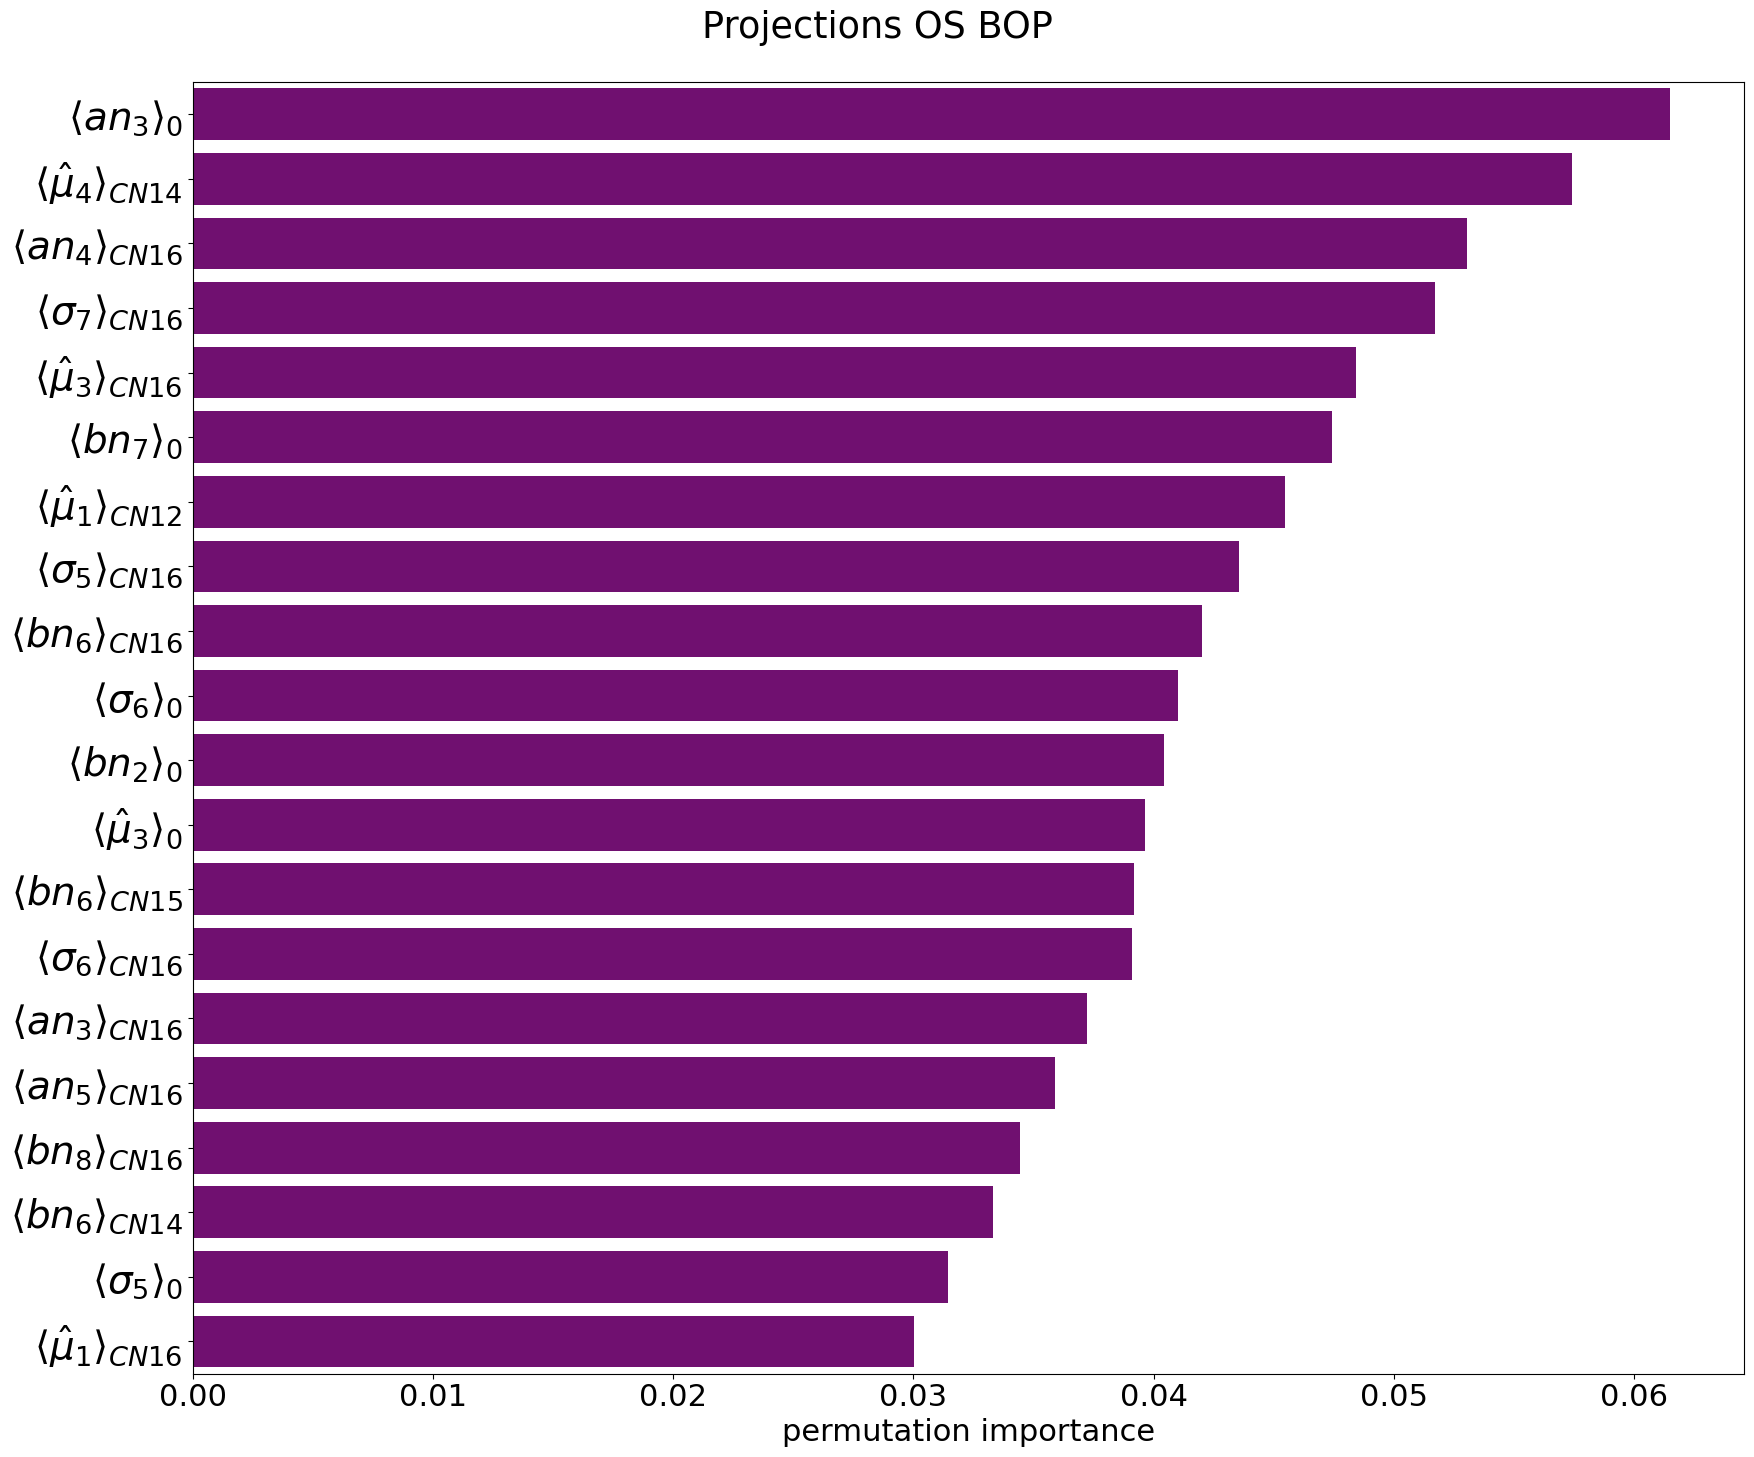

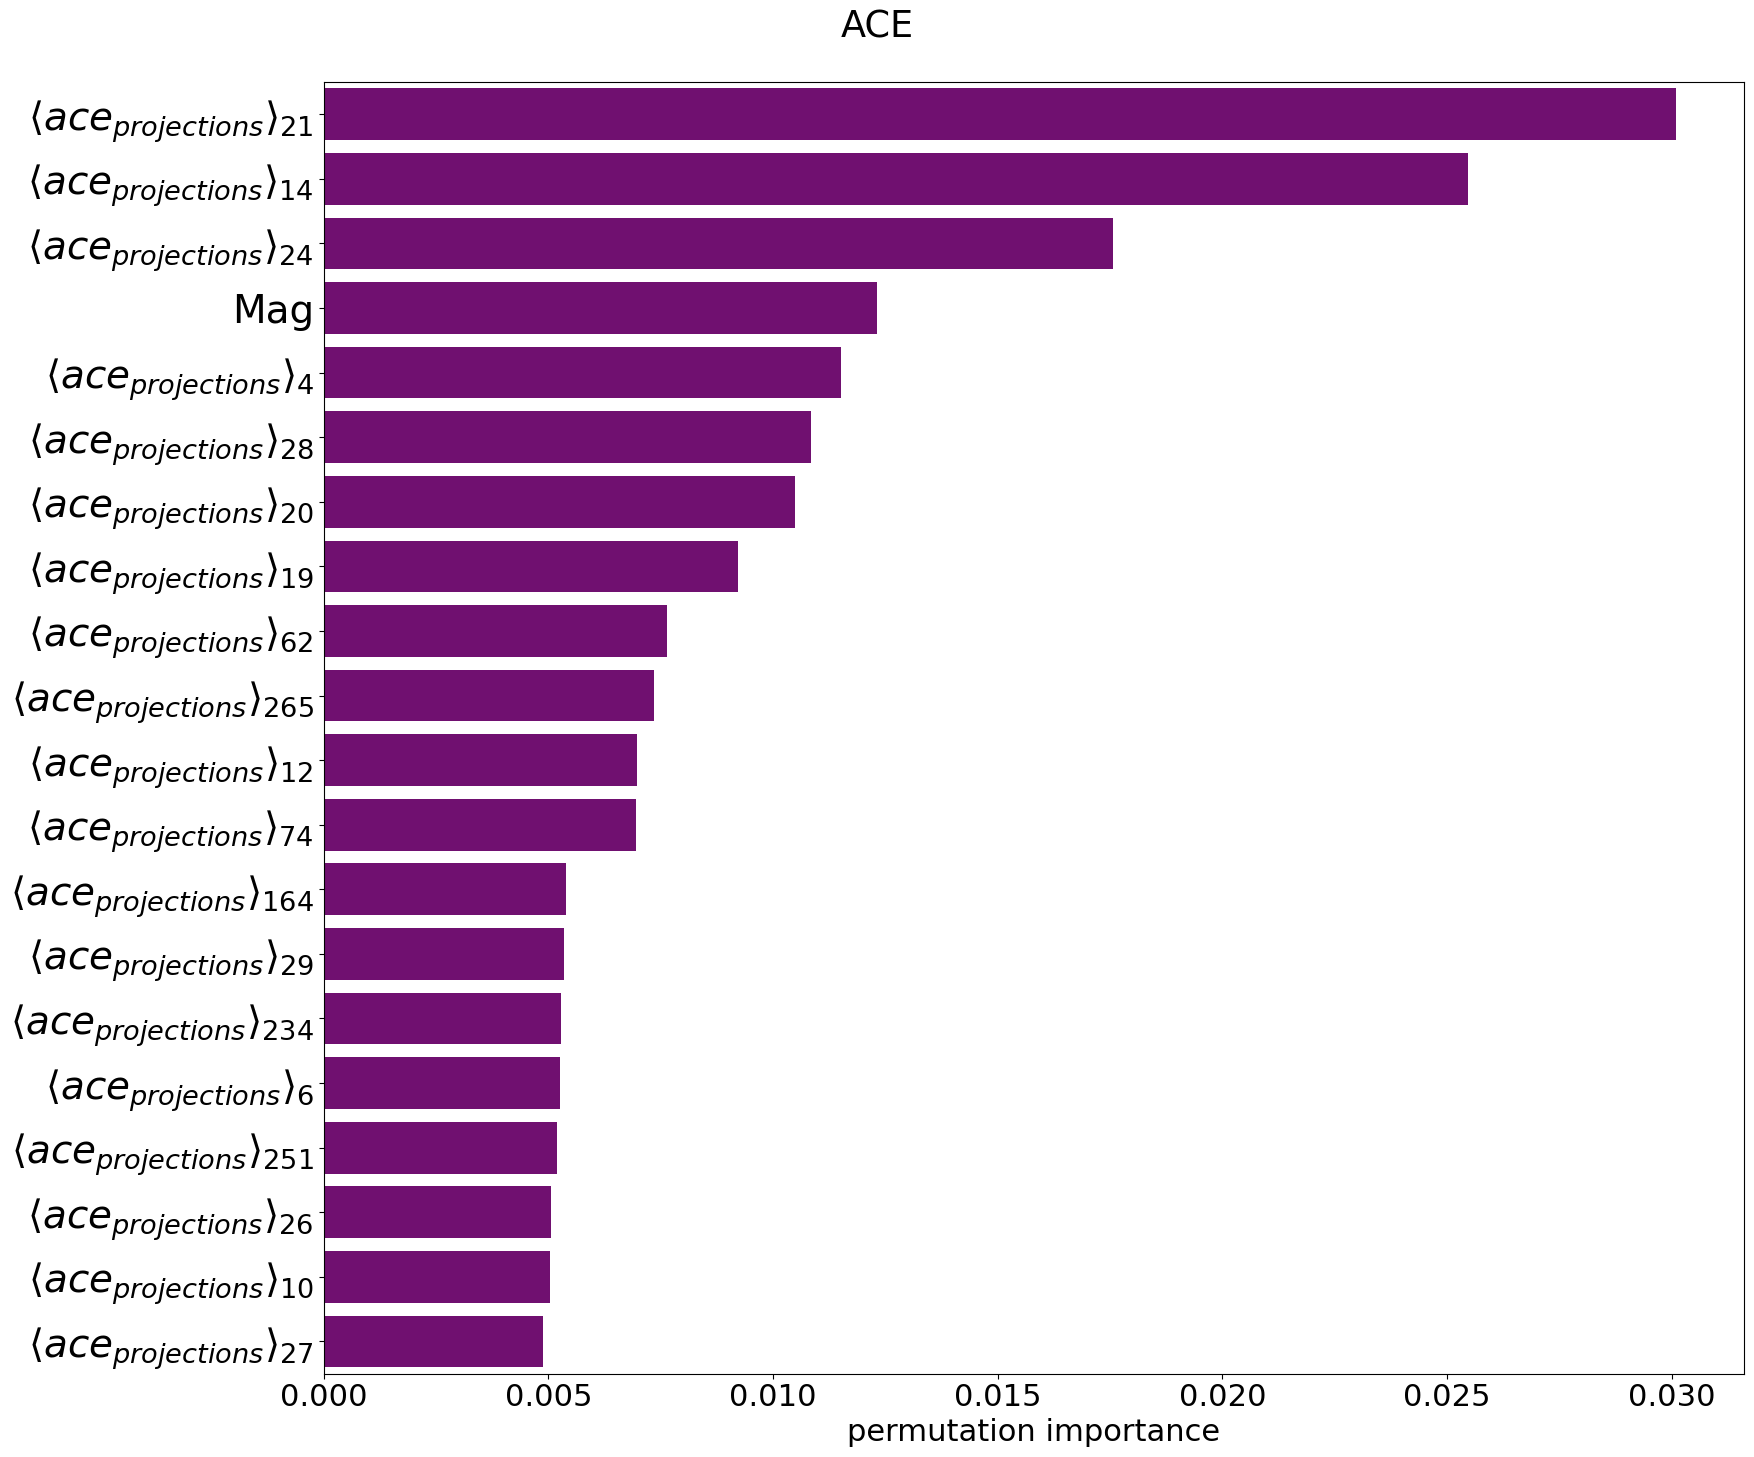

In [89]:
#for (model, name), timp in importances.items():
for (model, name), timp in importances.items(): #['Projections OS BOP', 'dataset + Projections OS BOP']:
#    pimp = timp[timp.index != 'Mag']
    fig, ax = plt.subplots(figsize=(18, 15))
    x = timp['importances_mean'][:20]
    sns.barplot(y=timp.index[:20], x=x , ax=ax, color='Purple')
    ylabels = [get_str_formatted(fname) for fname in x.index]
    ax.set_xlabel('permutation importance')
    ax.set_yticklabels(ylabels, fontsize=28)
    fig.suptitle(name.replace('dataset', 'polyhedra'))
    fig.tight_layout()
    nameforfile  = name.replace(' ','')
    fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_permutation_importance_{nameforfile}.pdf')

# Errors by phase by model

In [90]:
train_errors = {}
rmse = {}

In [91]:
OptimalFittedScores.sort_values(by='test', inplace=True)

In [92]:
for combi, errors in OptimalFittedScores.iterrows():
    if 'sOS' in combi[1]:
        continue
    print(combi)
    model = OptimalFittedModels[combi]
    nselected = FCresults[combi]['test'].argmin()
    selected = FCresults[combi].index[:nselected]
    predictions = model.predict(DS.Features[combi[1]][selected].loc[DS.samplesplit['test']])
    train_errors[combi] = np.abs(predictions - DS.target[DS.samplesplit['test']])*1000
    rmse[combi] = {}
    for phase in DS.BS.Phase.unique():
        thiserrors = train_errors[combi][DS.BS.Phase == phase]**2
        rmse[combi][phase] =  np.sqrt(thiserrors.sum()/len(thiserrors))
    rmse[combi]['total'] = errors['test']*1000

('Kernel Ridge', 'Projections OS BOP')
('Kernel Ridge', 'SOAP_specific')
('Kernel Ridge', 'Canonical BOP')
('Kernel Ridge', 'ACE')
('Kernel Ridge', 'ACE_CNAV')


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


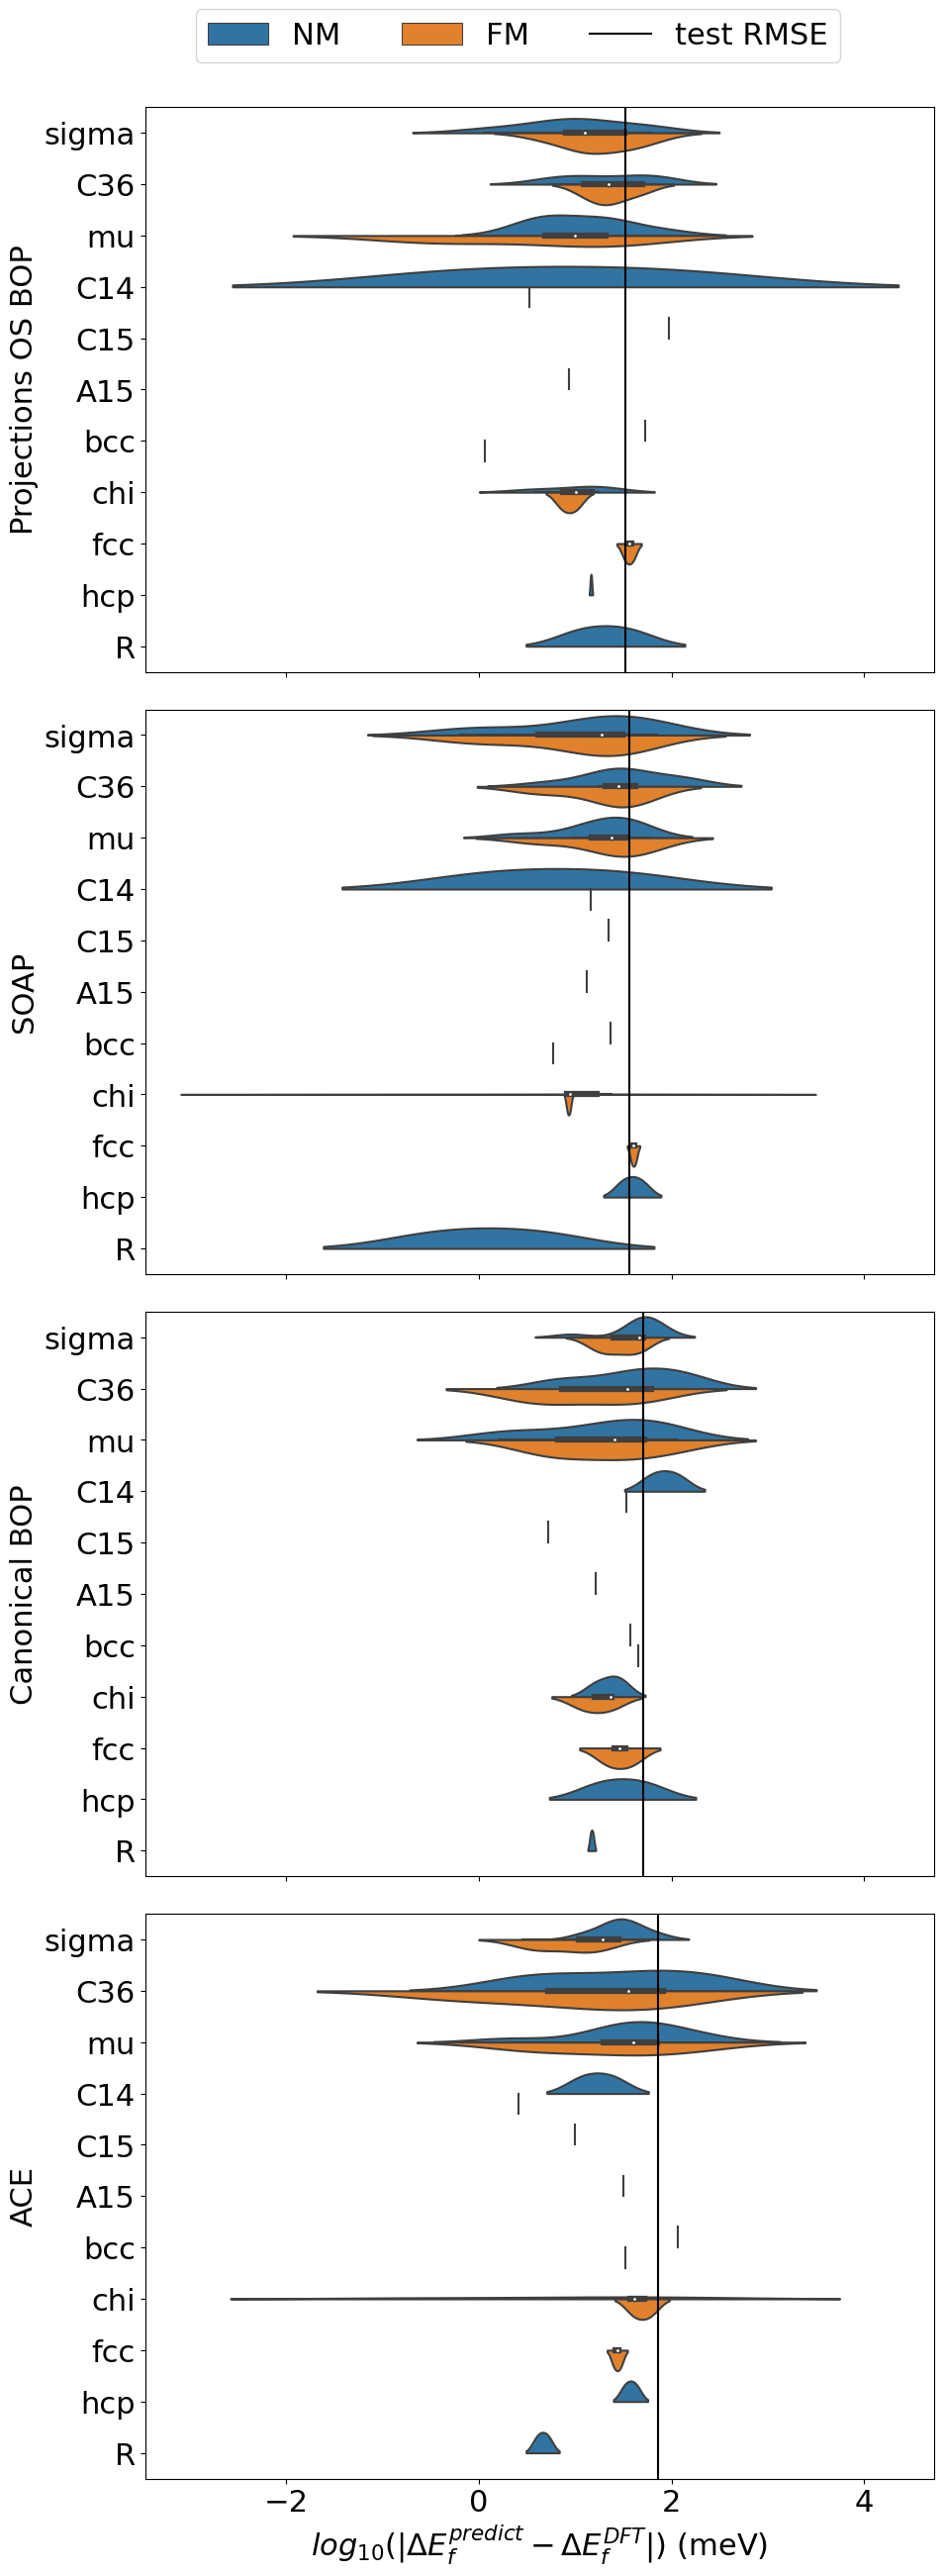

In [93]:
fig, axes = plt.subplots(len(OptimalFittedScores)-1, 1, sharex=True, figsize=(10, 5*len(train_errors)))
#for (combi, errors), ax in zip(train_errors.items(), axes):
for (combi, thisrmse), ax in zip(OptimalFittedScores.iterrows(), axes):
    if 'sOS' in combi [1]:
        continue
    sns.violinplot(
        x = np.log10(np.abs(train_errors[combi])),
        y = DS.StructureNames,
        hue=DS.Features['dataset']['Mag'], 
        ax=ax, split=True)
    ax.axvline(np.log10(thisrmse['test']*1000),color='k', label='rmse')
    ax.get_legend().remove()
    ax.set_xlabel('')
    ax.set_ylabel(combi[1].replace('_specific', ''))
fig.tight_layout()
label = axes[-1].set_xlabel(r'$log_{10}(| \Delta E_{f}^{predict} - \Delta E_{f}^{DFT}|)$ (meV)')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles , ['NM','FM', 'test RMSE'], bbox_to_anchor = (0.9, 1.2), ncol = 3)
fig.savefig(os.path.join(DS.dataset,'graphs',f'{DS.dataset}_violinerrors_{target_case}_testing.eps'))

In [94]:
rmsedf = pd.DataFrame.from_dict(rmse, orient = 'index')

In [95]:
rmsedf.sort_values(by=('Kernel Ridge', 'Projections OS BOP'), axis = 1, inplace=True)

In [96]:
rmsedf.sort_values(by='total', inplace=True)

<AxesSubplot:>

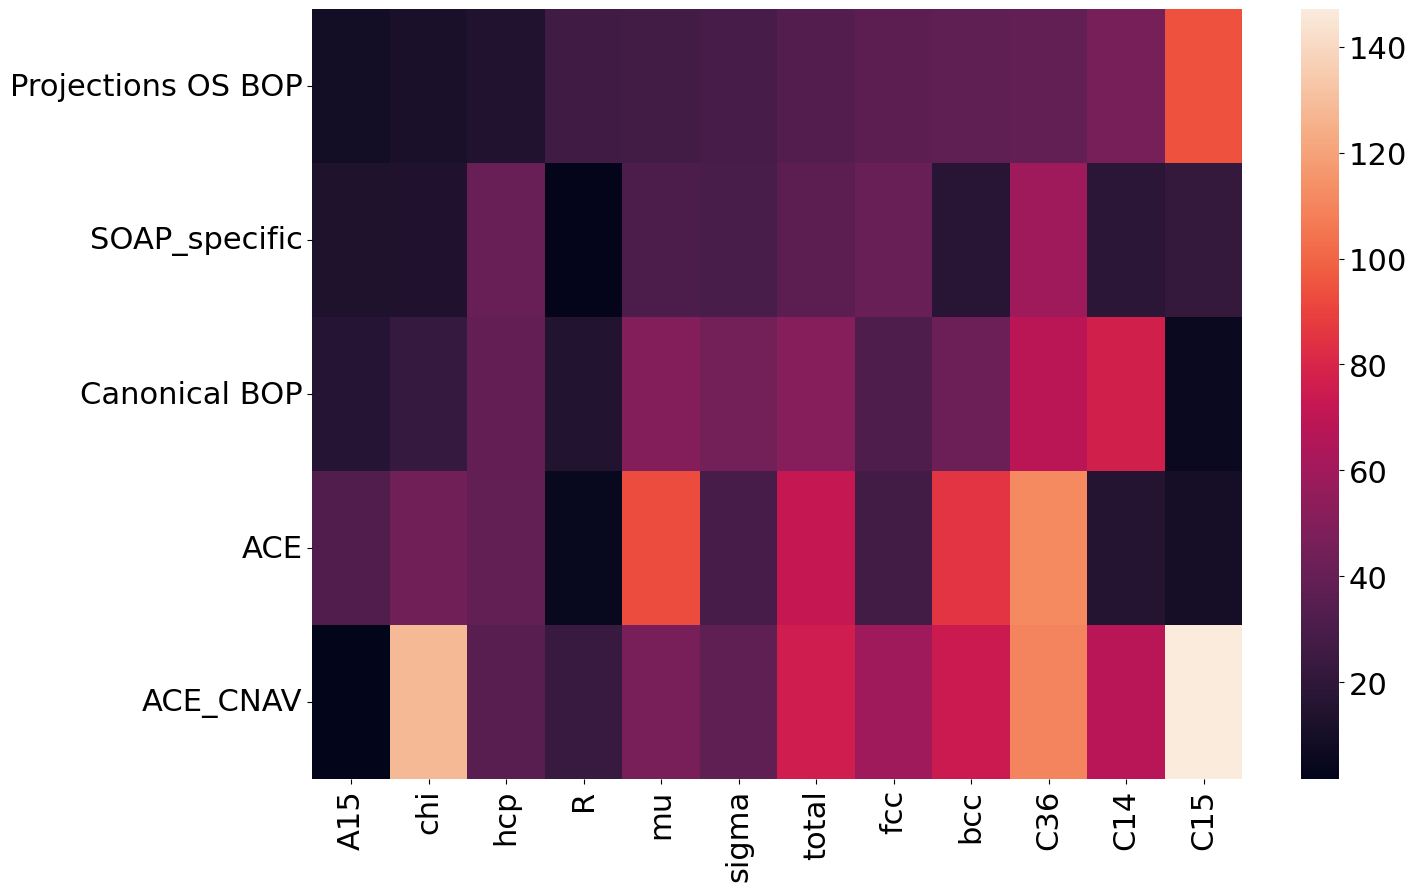

In [98]:
sns.heatmap(rmsedf.loc['Kernel Ridge'])

# Errors by Mag 

In [100]:
for combi,thiserrors in train_errors.items():
    fm_errors = thiserrors[thiserrors.index.str.contains('FM$',regex=True)]
    nm_errors = thiserrors[thiserrors.index.str.contains('NM$',regex=True)]
    break

Text(0.5, 0, '$\\Delta E_{FM} - \\Delta E_{NM}$')

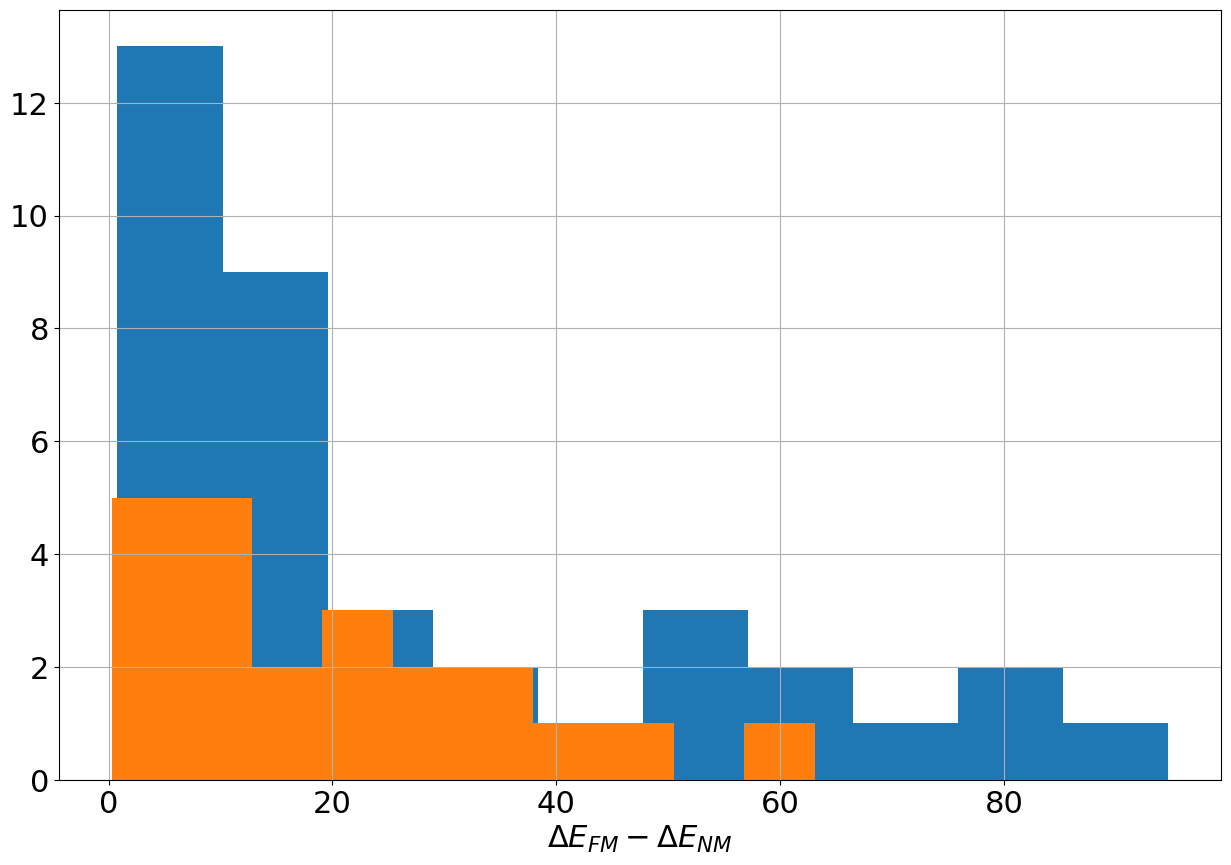

In [101]:
ax = nm_errors.hist()
fm_errors.hist(ax=ax)
ax.set_xlabel(r'$\Delta E_{FM} - \Delta E_{NM}$')

# convex hulls (binaries only)

In [108]:
from Tools.DatasetTools.Tools import Plotting
P = Plotting()

In [109]:
from importlib.machinery import SourceFileLoader
P = SourceFileLoader('Plotting', 'Tools/DatasetTools/Tools.py').load_module().Plotting()

In [110]:
components = DS.components

In [111]:
predictedBS = copy.copy(DS.BS.loc[DS.target.index])

In [118]:
predictedBS['EF'] = Prediction[combi]

In [122]:
verts = {}
chulls = {}
phasepoints = {}

PhasesBS = {mag: {phase: predictedBS[(predictedBS.Phase == phase) & predictedBS.index.str.contains(mag)] for phase in predictedBS.Phase.unique()} for mag in ['FM', 'NM', '']}

In [123]:
remove = []
for mag, phasesbs in PhasesBS.items():
    for phase, bs in phasesbs.items():
        if len(bs) < 3:
            remove.append((mag, phase))

In [125]:
[PhasesBS[remove_mag].pop(remove_phase) for (remove_mag, remove_phase) in remove]

[                                                      V         E0  \
 Fe_pv4Mo_sv2.C15-A2B.FM  bulk  C15-A2B.FM  12.307425 A   -9.135294   
 Mo_sv6.C15.FM                bulk  C15.FM  16.461406 A  -10.567501   
 
                                        B                         fit       xc  \
 Fe_pv4Mo_sv2.C15-A2B.FM  177.924519 GPa   murnaghan  volume_relaxed   PBE-PAW   
 Mo_sv6.C15.FM            235.215184 GPa   murnaghan  volume_relaxed   PBE-PAW   
 
                         encut deltak ncrash  nelem  ...  num_atom_A  \
 Fe_pv4Mo_sv2.C15-A2B.FM   450  0.018      0      2  ...           4   
 Mo_sv6.C15.FM             450  0.020      0      1  ...           6   
 
                          num_atom_B num_atoms     Fe_pv     Mo_sv  EF_nmhcp  \
 Fe_pv4Mo_sv2.C15-A2B.FM           2         6  0.666667  0.333333  0.012986   
 Mo_sv6.C15.FM                     0         6  0.000000  1.000000  0.366750   
 
                          EF_nmfcc  EF_fmbcc  Phase        EF  
 Fe_pv4Mo_sv2

FM [('sigma', 28), ('C36', 18), ('mu', 20), ('C14', 7), ('A15', 3), ('chi', 7), ('fcc', 3), ('hcp', 3)]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


NM [('sigma', 30), ('C36', 31), ('mu', 30), ('C14', 7), ('C15', 3), ('A15', 3), ('bcc', 5), ('chi', 13), ('fcc', 4), ('hcp', 4), ('R', 8)]
 [('sigma', 58), ('C36', 49), ('mu', 50), ('C14', 14), ('C15', 5), ('A15', 6), ('bcc', 7), ('chi', 20), ('fcc', 7), ('hcp', 7), ('R', 8)]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


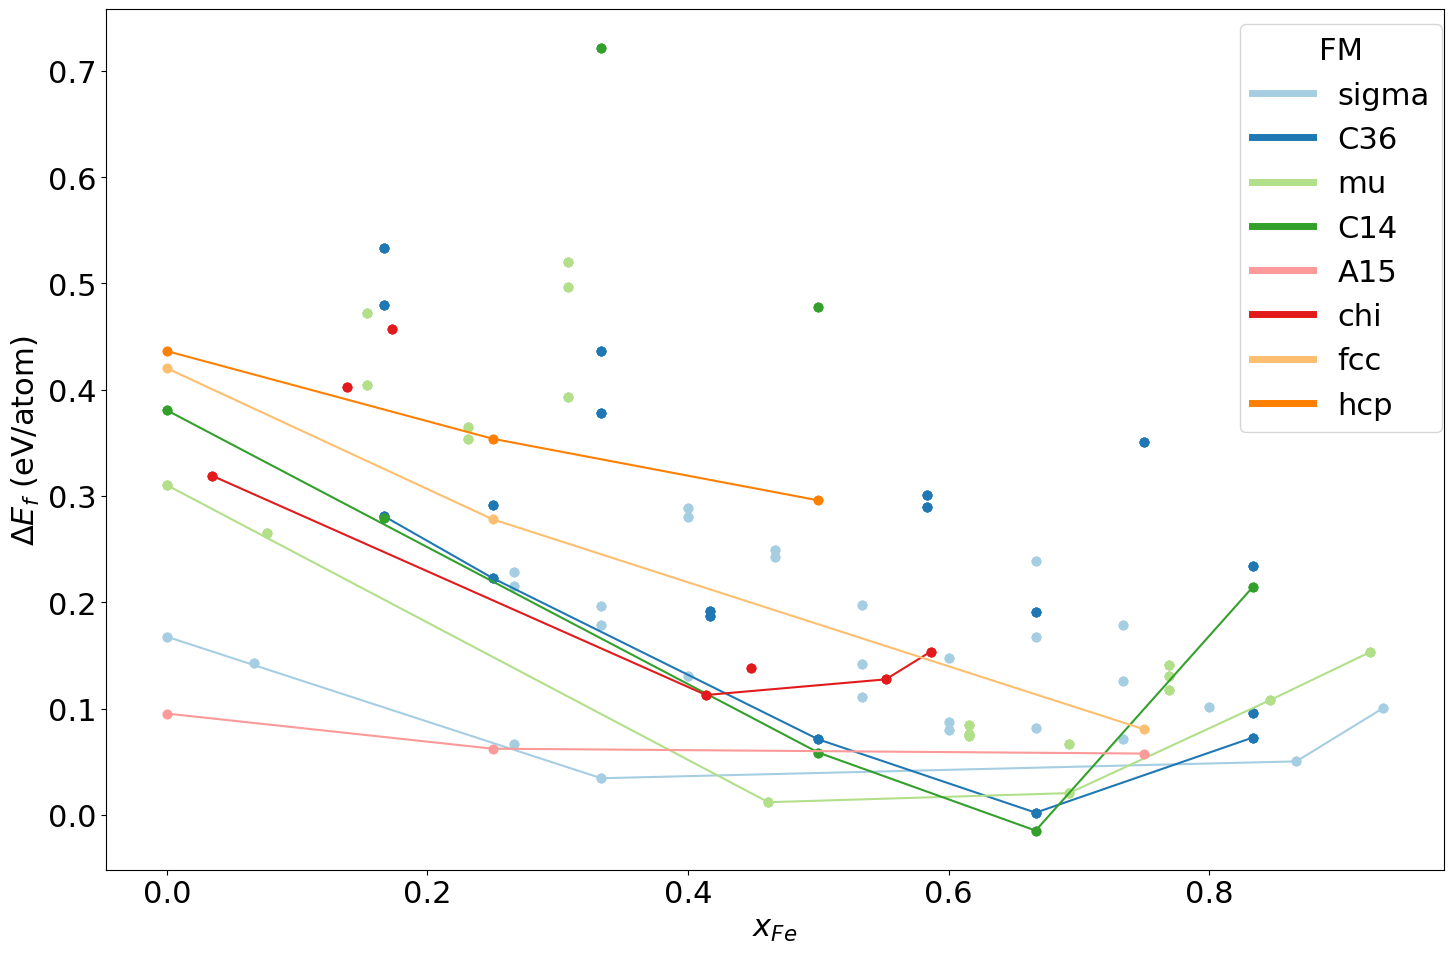

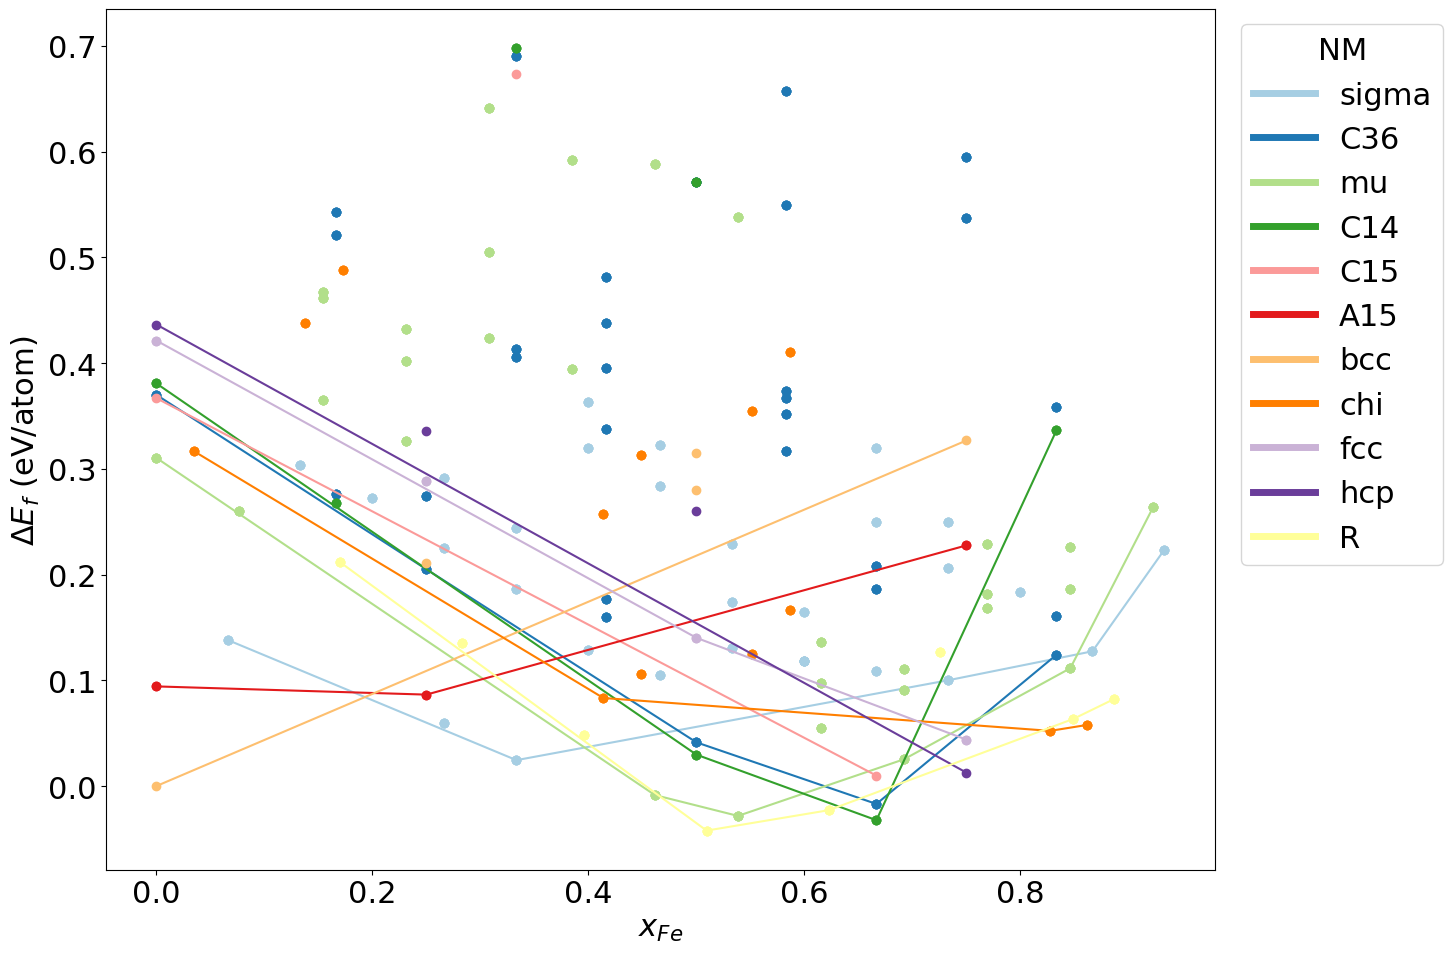

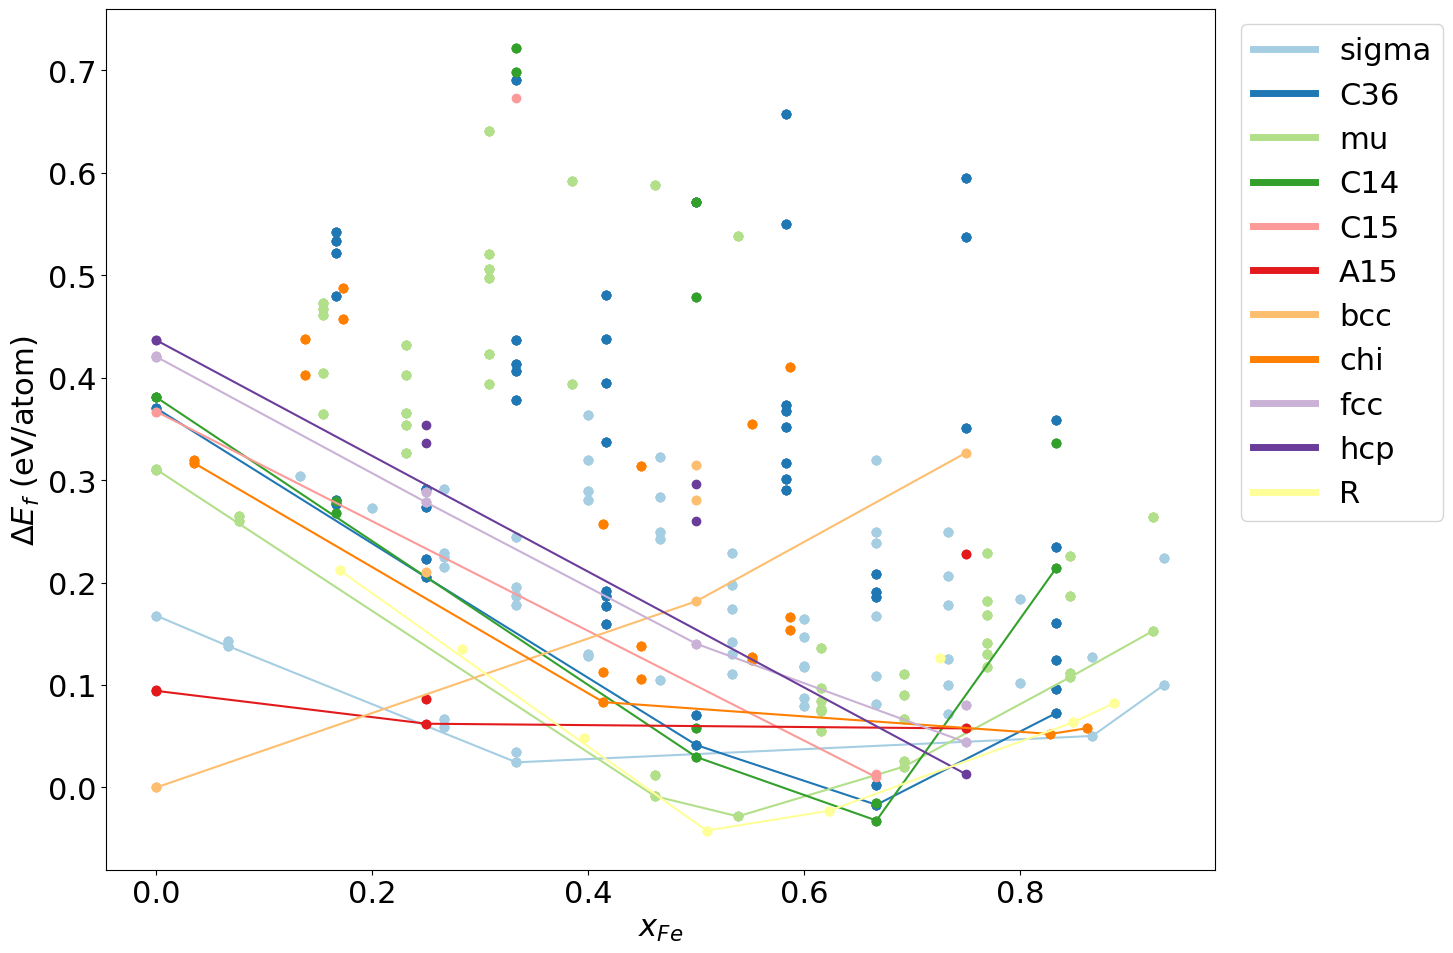

In [128]:
for mag, PhaseBS in  PhasesBS.items():
    print(mag, [(phase, len(BS))  for phase, BS in PhaseBS.items()] )
    points = P.get_x_ef_points(PhaseBS, components, property=target_case)
    chulls = P.get_convex_hulls(PhaseBS, components, return_points = False, getproperty = target_case)
    pallette = sns.color_palette("Paired", n_colors=len(PhaseBS)+1)
    #pallette.pop(-2)
    colors = {phase: color for phase, color in zip(PhaseBS.keys(), pallette)}
    fig, ax = plt.subplots()
    labels=[]
    handles = []
    for phase, chull in chulls.items():
        for visible_facet in chull.simplices[chull.good]:
            ax.plot(points[phase][:,0] , points[phase][:,1], 'o', color = colors[phase])
            l = ax.plot(chull.points[visible_facet,0], chull.points[visible_facet,1], color=colors[phase])
        handles.append(l[0])
        labels.append(phase)
    leg = ax.legend(handles, labels, bbox_to_anchor=(1.01,1), title=mag)
    setlw = [ha.set_linewidth(5) for ha in leg.get_lines() ]
    ax.set_ylabel(r'$\Delta E _f$ (eV/atom)')
    ax.set_xlabel(rf'$x_{{{components[0]}}}$')
    fig.tight_layout()
    fig.savefig(os.path.join(DS.dataset, 'graphs',f'{DS.dataset}_ConvxHulls_{target_case}_{mag}.eps' ))